# 01 · Pantheon+SH0ES SNe

Eight cosmological scenarios over **Pantheon+SH0ES** (1701 SNe Ia with the full
STAT+SYS covariance), from the simplest (FlatLCDM 2D) to the most general
(w0waCDM 4D, with or without Cepheids).

### Shared pipeline

- Sampling: `build_chi2_dataset` with slices + random cloud, cached in `outputs/datasets/`.
- Training: `train_xgb(log_target=True)` with model cache.
- XGBoost hyperparameters: `n_estimators=3000, learning_rate=0.03, max_depth=10`,
  `tree_method='hist'`, early stopping with `min_delta=1e-4` (auto for log targets).
- Contours: `res=100, sigma=2.0, theory_threshold=12`.
- SHAP values are in shifted-log10 chi2; a contribution of 0.5 ~ factor x3 in chi2.


## Index

| Sec. | Scenario                              | Dim | Cepheids (SH0ES) | Notes |
|------|---------------------------------------|-----|------------------|-------|
| [1.1](#1-1) | **FlatLCDM**                  | 2   | **NO** (M=-19.239 fixed, no mask) | Simplest baseline |
| [1.2](#1-2) | **Non-flat LambdaCDM** (Ode free) | 3 | **YES**         | Allows curvature Om_k = 1 - Om - Ode |
| [1.3](#1-3) | **FlatLCDM + free M**         | 3   | **YES**          | M absolute as a parameter (not marginalized) |
| [1.4](#1-4) | **FlatLCDM + SALT2 alpha/beta** | 4 | **YES**          | Stretch (alpha) and color (beta) free |
| [1.5](#1-5) | **wCDM**                      | 3   | **YES**          | Constant dark energy equation of state |
| [1.6](#1-6) | **w0waCDM with SH0ES**        | 4   | **YES**          | CPL: w(z) = w0 + wa*z/(1+z) with Cepheids |
| [1.7](#1-7) | **w0waCDM without SH0ES**     | 4   | **NO** (standard z>0.01 mask) | Same model, no Cepheid anchor |
| [1.8](#1-8) | **w0waCDM with z>0.25**       | 4   | **NO** (aggressive cut, no calibrators) | Remove local flow and Cepheids |

### About Cepheids (SH0ES)

Pantheon+ includes a subset of SNe Ia in galaxies with direct Cepheid distance
measurements (SH0ES calibrators). When `use_cepheid_calibrators=True`, those
SNe do NOT follow the cosmological model: their distance modulus is fixed to
`CEPH_DIST`. The rest do follow it. This anchors the luminosity scale and thus
H0, which is otherwise degenerate with M.


## <a id="setup"></a>Setup (run first)


In [42]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_pantheon_plus
from cosmoml.theory.sne import chi2_sne

from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "01_SN_Panth+"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Set to True to retrain models (ignore cache)
FORCE_RETRAIN = False

print(f"Datasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/{SECTION}_*.png


## <a id="1-1"></a>1.1 FlatLCDM — 2D (Om, H0), no Cepheids

**Model:** `FlatLambdaCDM` (Om, H0), absolute magnitude M fixed at the fiducial.
**Data:** Pantheon+SH0ES, no mask — all 1701 SNe follow the cosmological model.
**Cepheids:** **NO** (`use_cepheid_calibrators=False`, `apply_mask=False`).
M = -19.23904 (calibrated for Om=0.334, H0=73.6).

Simplest baseline: no Cepheid treatment, no zHEL/zHD correction.


In [43]:
SECTION = "1_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0"]
M_CALIBRATED = -19.23904

sne = load_pantheon_plus(apply_mask=False)
print(f"Pantheon+ (no mask): {len(sne)} SNe")

def chi2_fn(Om, H0):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M=M_CALIBRATED,
        use_cepheid_calibrators=False,
        use_zhel_correction=False,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.6])))
_m.limits = [(0.1, 0.5), (65, 80)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (no mask): 1701 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3612  H0=73.3094
chi2(best-fit) = 1752.51


In [44]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(REF['Om']-0.10, REF['Om']+0.10),
                     H0=(REF['H0']-2.5, REF['H0']+2.5), _n=10_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_1_dataset.csv)
Evaluating chi2 at 10000 points across 11 cores...
     2000/10000 ( 20.0%) | elapsed   50.4s | ETA  201.6s |     40 pts/s
     4000/10000 ( 40.0%) | elapsed   97.3s | ETA  145.9s |     41 pts/s
     6000/10000 ( 60.0%) | elapsed  143.8s | ETA   95.9s |     42 pts/s
     8000/10000 ( 80.0%) | elapsed  188.3s | ETA   47.1s |     42 pts/s
    10000/10000 (100.0%) | elapsed  220.7s | ETA    0.0s |     45 pts/s
  done in 220.8s
  anchor {'Om': 0.36115726940026527, 'H0': 73.30943637441906} -> chi2=1752.508 repeated 2000x
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_1_dataset.csv (12000 rows)
min chi2 = 1752.508


  target in shifted-log10: range [0.000, 2.944]
  training: 13.67s | R2=0.99934 | best_iter=536/3000  (early stop, ~82% saved)
  model cached: 1_1_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_learning_curve.png


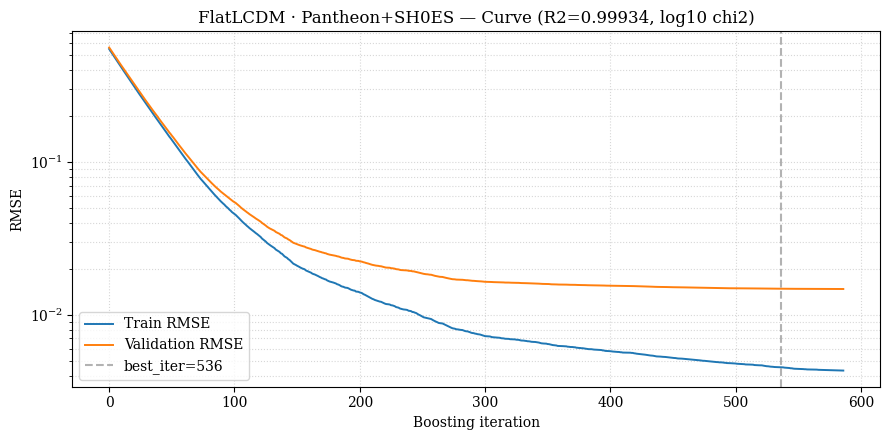

In [45]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_Om_H0.png


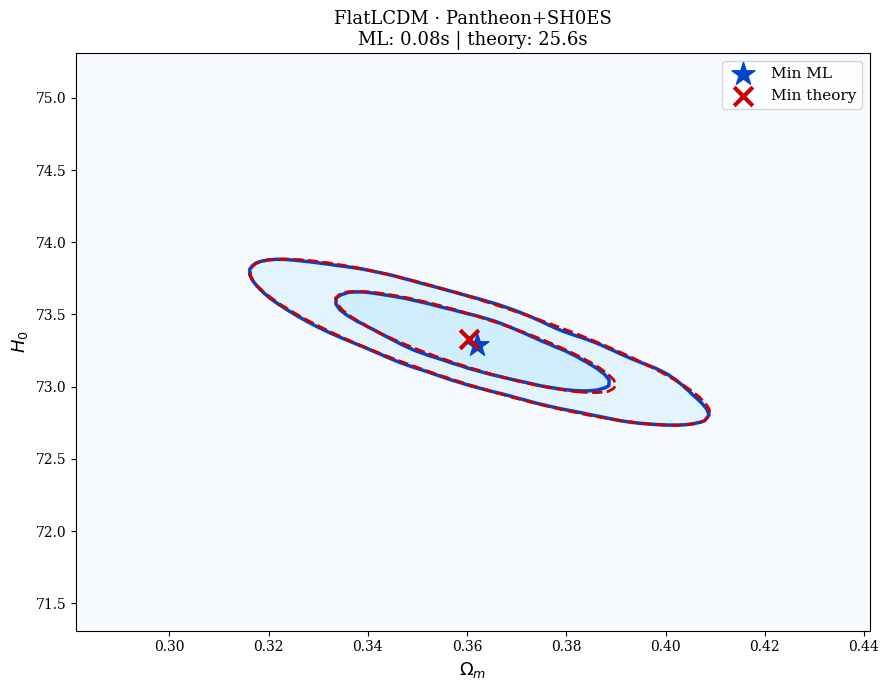

{'Z_ml': array([[2299.3103, 2296.742 , 2292.1292, ..., 1862.7004, 1861.3296,
         1860.6058],
        [2293.428 , 2290.8948, 2286.3335, ..., 1860.1504, 1858.8103,
         1858.0997],
        [2282.8677, 2280.383 , 2275.8958, ..., 1855.6925, 1854.4313,
         1853.7588],
        ...,
        [1844.0277, 1844.5535, 1845.5171, ..., 2238.034 , 2243.1743,
         2246.103 ],
        [1847.1562, 1847.7332, 1848.786 , ..., 2247.6262, 2252.4119,
         2255.109 ],
        [1848.8455, 1849.4501, 1850.5519, ..., 2252.9788, 2257.5415,
         2260.0938]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.07582330703735352,
 'time_th': 25.55637502670288}

In [46]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="H0",
    x_range=(REF['Om']-0.08, REF['Om']+0.08),
    y_range=(REF['H0']-2.0, REF['H0']+2.0),
    fixed={},
    theory_fn=chi2_fn,
    title=r"FlatLCDM · Pantheon+SH0ES",
    x_label=r"$\Omega_m$", y_label=r"$H_0$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_H0.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_beeswarm.png


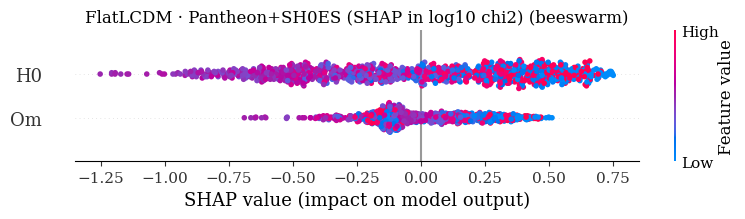

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_bar.png


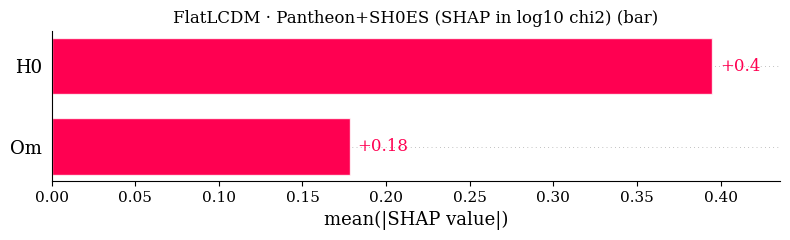

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_waterfall.png


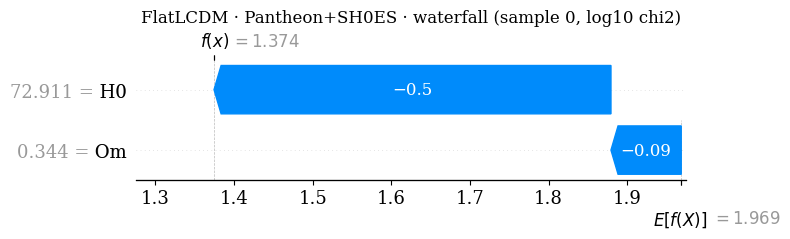

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

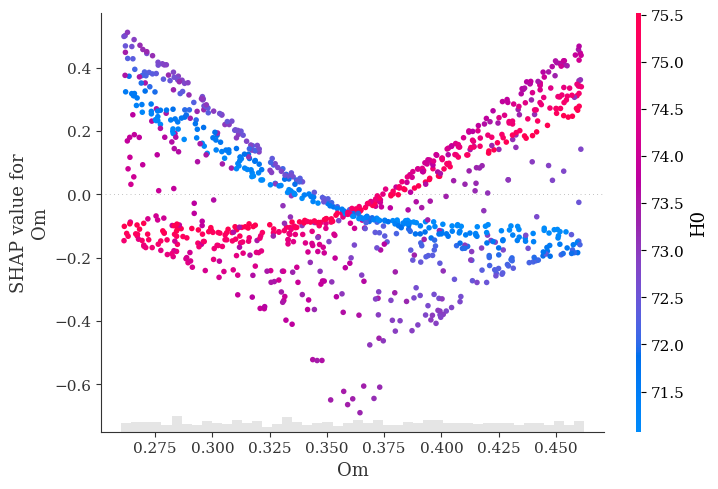

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_H0.png


<Figure size 640x480 with 0 Axes>

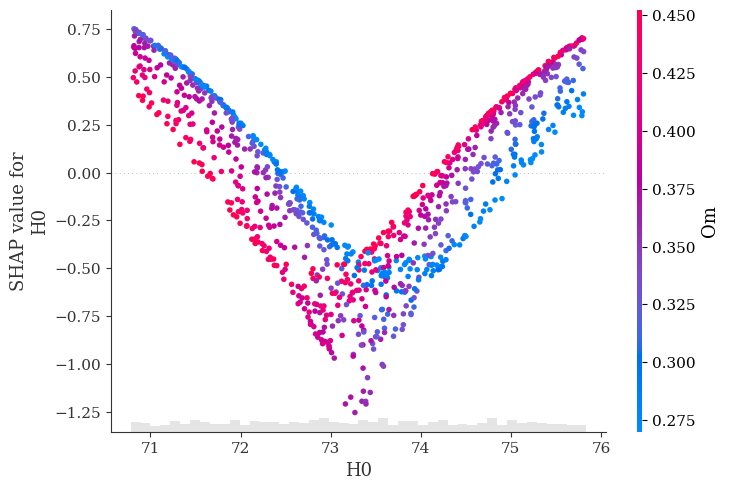

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_H0.png')]

In [47]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="FlatLCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="FlatLCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-2"></a>1.2 Non-flat LambdaCDM — 3D (Om, Ode, H0) with Cepheids

**Model:** `LambdaCDM` (Om, Ode, H0); curvature Om_k = 1 - Om - Ode is free.
**Data:** Pantheon+SH0ES with the standard mask `(zHD>0.01) | IS_CALIBRATOR`.
**Cepheids:** **YES** — calibrators anchor H0 via `mu = CEPH_DIST`.

Tests flatness: the Om-Ode contour should lie close to the Om + Ode = 1 line if
the universe is spatially flat.


In [48]:
SECTION = "1_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "Ode", "H0"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (mask z>0.01 OR calibrators): {len(sne)} SNe, calibradores={sne.is_calib.sum()}")

def chi2_fn(Om, Ode, H0):
    return chi2_sne(
        sne, model="LambdaCDM",
        Om=Om, Ode=Ode, H0=H0,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, 0.7, 73.04])))
_m.limits = [(0.1, 0.5), (0.4, 1.0), (65, 80)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  Ode={REF['Ode']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (mask z>0.01 OR calibrators): 1657 SNe, calibradores=77
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3036  Ode=0.6251  H0=73.4603
chi2(best-fit) = 1451.70


In [49]:
def builder():
    N = 7_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=(0.0, 0.8), Ode=(0.0, 1.2), H0=REF['H0'],          _n=N),
            dict(Om=(0.0, 0.8), H0=(20, 100),   Ode=REF['Ode'],        _n=N),
            dict(H0=(20, 100),  Ode=(0.0, 1.2), Om=REF['Om'],          _n=N),
        ],
        random_box=dict(Om=(0.0, 1.0), Ode=(0.0, 1.5), H0=(20, 100)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_2_dataset.csv)
Evaluating chi2 at 41000 points across 11 cores...
     2000/41000 (  4.9%) | elapsed   71.1s | ETA 1386.0s |     28 pts/s


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/sit

     4000/41000 (  9.8%) | elapsed  132.8s | ETA 1228.1s |     30 pts/s


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/sit

     6000/41000 ( 14.6%) | elapsed  198.4s | ETA 1157.3s |     30 pts/s
     8000/41000 ( 19.5%) | elapsed  257.9s | ETA 1063.9s |     31 pts/s
    10000/41000 ( 24.4%) | elapsed  306.2s | ETA  949.3s |     33 pts/s
    12000/41000 ( 29.3%) | elapsed  373.0s | ETA  901.5s |     32 pts/s
    14000/41000 ( 34.1%) | elapsed  434.1s | ETA  837.1s |     32 pts/s
    16000/41000 ( 39.0%) | elapsed  495.0s | ETA  773.5s |     32 pts/s
    18000/41000 ( 43.9%) | elapsed  555.2s | ETA  709.4s |     32 pts/s
    20000/41000 ( 48.8%) | elapsed  616.9s | ETA  647.7s |     32 pts/s


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:968: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/sit

    22000/41000 ( 53.7%) | elapsed  661.1s | ETA  570.9s |     33 pts/s
    24000/41000 ( 58.5%) | elapsed  719.9s | ETA  509.9s |     33 pts/s
    26000/41000 ( 63.4%) | elapsed  780.1s | ETA  450.1s |     33 pts/s
    28000/41000 ( 68.3%) | elapsed  836.7s | ETA  388.5s |     33 pts/s
    30000/41000 ( 73.2%) | elapsed  907.6s | ETA  332.8s |     33 pts/s
    32000/41000 ( 78.0%) | elapsed  972.5s | ETA  273.5s |     33 pts/s
    34000/41000 ( 82.9%) | elapsed 1043.8s | ETA  214.9s |     33 pts/s
    36000/41000 ( 87.8%) | elapsed 1092.5s | ETA  151.7s |     33 pts/s
    38000/41000 ( 92.7%) | elapsed 1159.9s | ETA   91.6s |     33 pts/s
    40000/41000 ( 97.6%) | elapsed 1221.8s | ETA   30.5s |     33 pts/s
  done in 1246.1s
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_2_dataset.csv (41000 rows)
min chi2 = 1451.722


  dropping 493 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.035]
  training: 13.38s | R2=0.99952 | best_iter=717/3000  (early stop, ~76% saved)
  model cached: 1_2_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_learning_curve.png


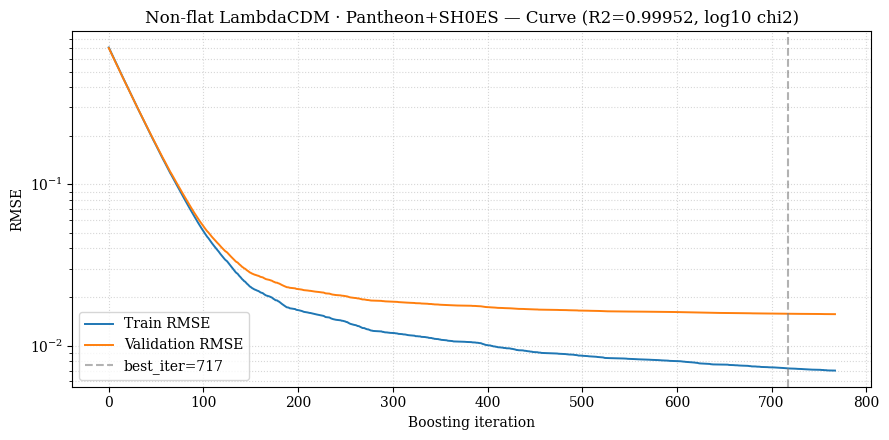

In [50]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"Non-flat LambdaCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $\Omega_\Lambda$ vs $\Omega_m$  ({'H0': 73.46034923581617}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Om_Ode.png


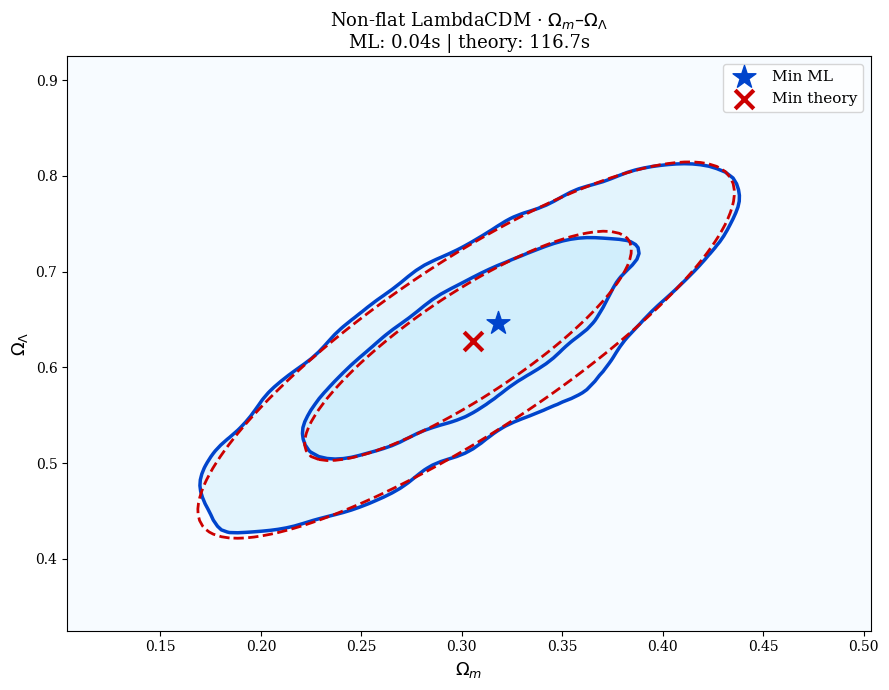

--- $H_0$ vs $\Omega_m$  ({'Ode': 0.6250539821887453}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Om_H0.png


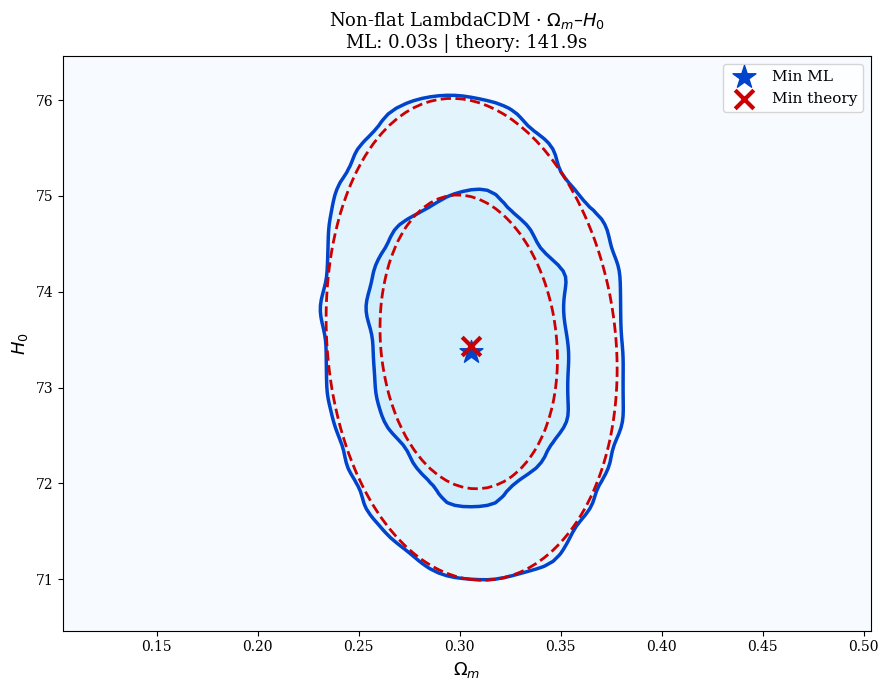

--- $H_0$ vs $\Omega_\Lambda$  ({'Om': 0.30359726739199294}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Ode_H0.png


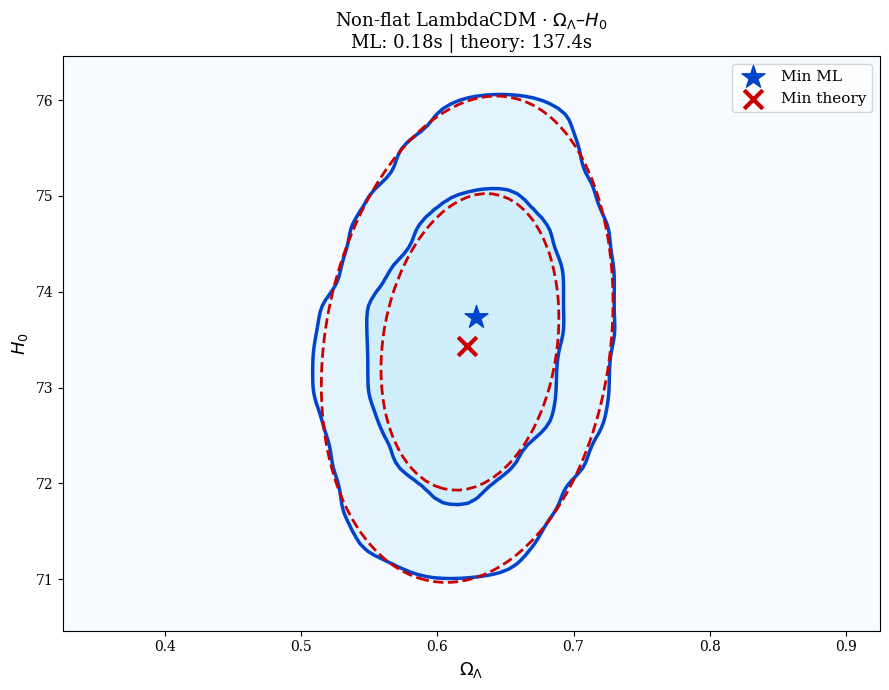

In [51]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.20, REF['Om']+0.20),
    Ode=(REF['Ode']-0.30, REF['Ode']+0.30),
    H0=(REF['H0']-3.0, REF['H0']+3.0),
)
LABELS = dict(Om=r"$\Omega_m$", Ode=r"$\Omega_\Lambda$", H0=r"$H_0$")

for x, y in [('Om','Ode'), ('Om','H0'), ('Ode','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"Non-flat LambdaCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_beeswarm.png


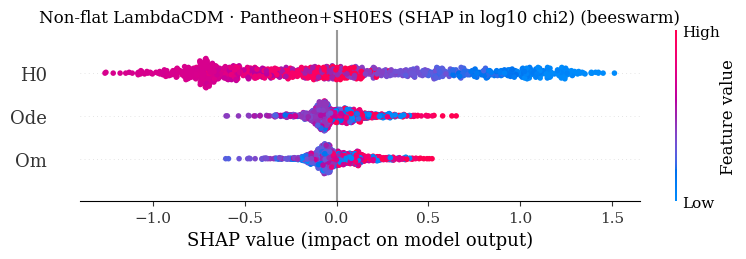

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_bar.png


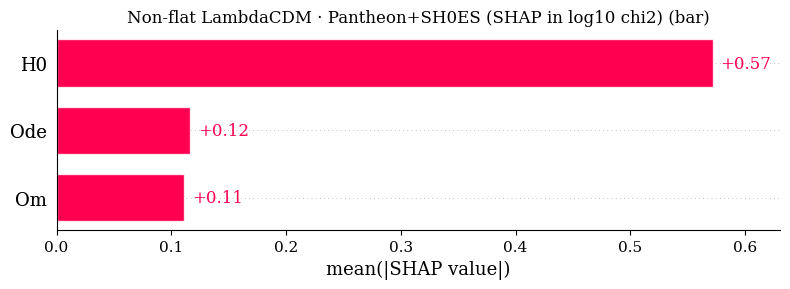

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_waterfall.png


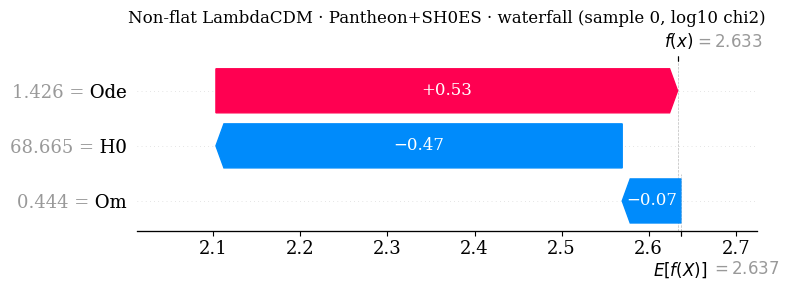

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

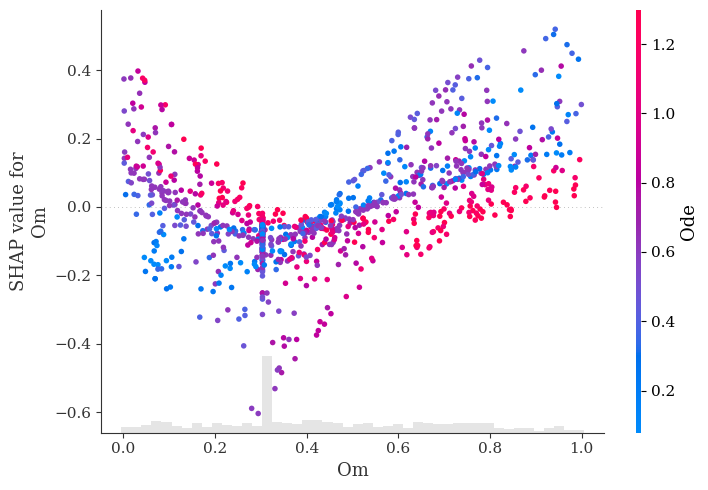

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Ode.png


<Figure size 640x480 with 0 Axes>

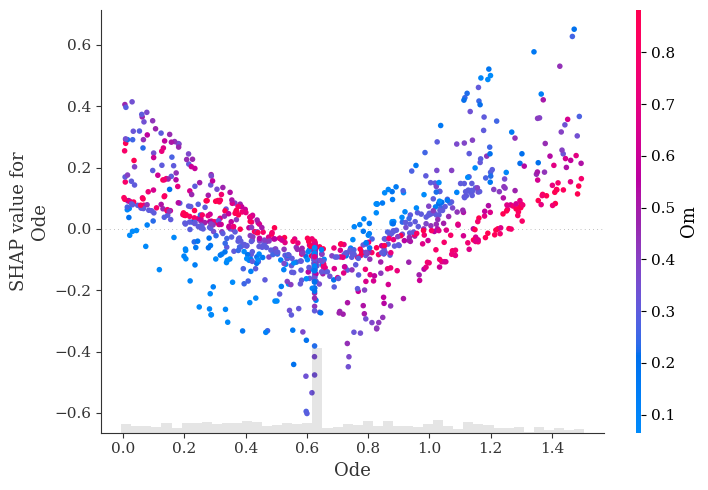

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

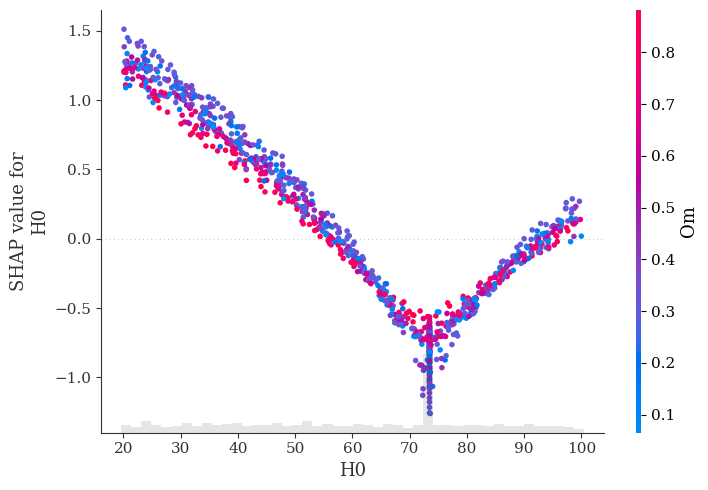

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Ode.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_H0.png')]

In [52]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="Non-flat LambdaCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="Non-flat LambdaCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-3"></a>1.3 FlatLCDM + free M — 3D (Om, H0, M) with Cepheids

**Model:** `FlatLambdaCDM` (Om, H0) with absolute magnitude M as a **free parameter**
(NOT marginalized).
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

Useful for visualizing the M–H0 degeneracy explicitly instead of marginalizing it out.


In [53]:
SECTION = "1_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "M"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (masked): {len(sne)} SNe")

def chi2_fn(Om, H0, M):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M=M,
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, -19.25])))
_m.limits = [(0.1, 0.5), (65, 80), (-19.4, -19.1)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  M={REF['M']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3317  H0=73.5325  M=-19.2441
chi2(best-fit) = 1452.02


In [54]:
def builder():
    N = 4_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(H0=(65, 80),  M=(-19.35, -19.15), Om=REF['Om'],   _n=N),
            dict(Om=(0.1, 0.5), M=(-19.35, -19.15), H0=REF['H0'],  _n=N),
            dict(Om=(0.1, 0.5), H0=(65, 80),       M=REF['M'],     _n=N),
            dict(Om=(0.2, 0.45), H0=(66, 78),     M=(-19.30, -19.20), _n=N),
        ],
        random_box=dict(Om=(0.1, 0.6), H0=(60, 85), M=(-19.40, -19.10)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_3_dataset.csv)
Evaluating chi2 at 31000 points across 11 cores...
     2000/31000 (  6.5%) | elapsed   57.2s | ETA  830.1s |     35 pts/s
     4000/31000 ( 12.9%) | elapsed  109.6s | ETA  740.1s |     36 pts/s
     6000/31000 ( 19.4%) | elapsed  159.3s | ETA  663.9s |     38 pts/s
     8000/31000 ( 25.8%) | elapsed  210.0s | ETA  603.6s |     38 pts/s
    10000/31000 ( 32.3%) | elapsed  251.8s | ETA  528.7s |     40 pts/s
    12000/31000 ( 38.7%) | elapsed  302.7s | ETA  479.3s |     40 pts/s
    14000/31000 ( 45.2%) | elapsed  351.4s | ETA  426.7s |     40 pts/s
    16000/31000 ( 51.6%) | elapsed  394.4s | ETA  369.8s |     41 pts/s
    18000/31000 ( 58.1%) | elapsed  440.7s | ETA  318.3s |     41 pts/s
    20000/31000 ( 64.5%) | elapsed  485.3s | ETA  266.9s |     41 pts/s
    22000/31000 ( 71.0%) | elapsed  531.5s | ETA  217.4s |     41 pts/s
    24000/31000 ( 77.4%) | elapsed  581.2s | ETA  169.5s |  

  target in shifted-log10: range [0.000, 4.475]
  training: 23.08s | R2=0.99675 | best_iter=1266/3000  (early stop, ~58% saved)
  model cached: 1_3_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_learning_curve.png


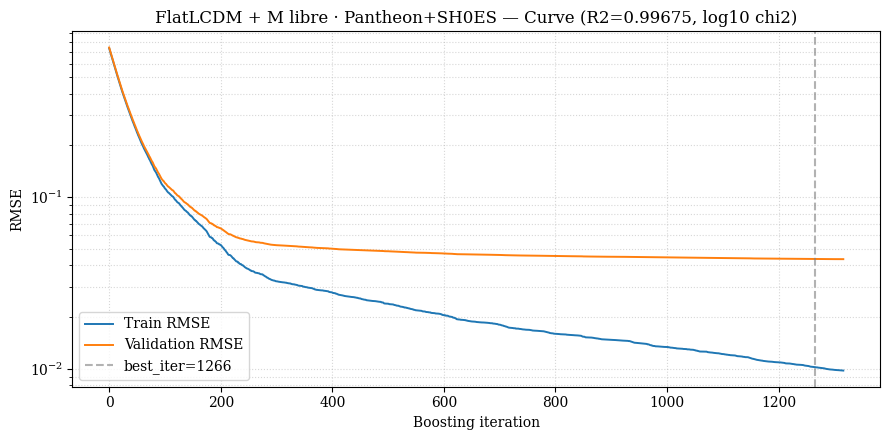

In [55]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM + M libre · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'M': -19.244089439867864}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_Om_H0.png


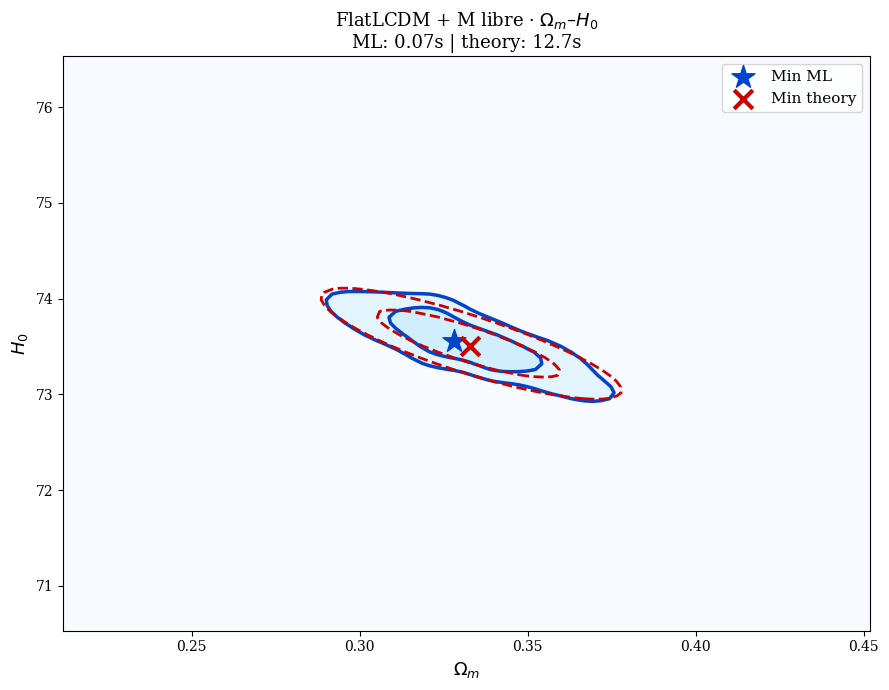

--- $M$ vs $\Omega_m$  ({'H0': 73.53246993819143}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_Om_M.png


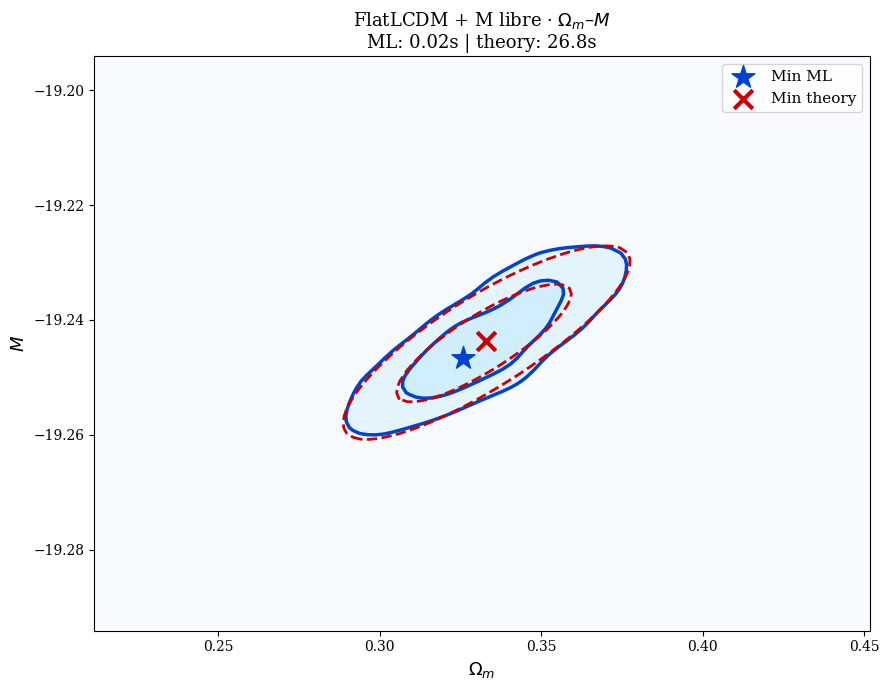

--- $M$ vs $H_0$  ({'Om': 0.33174608165187713}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_H0_M.png


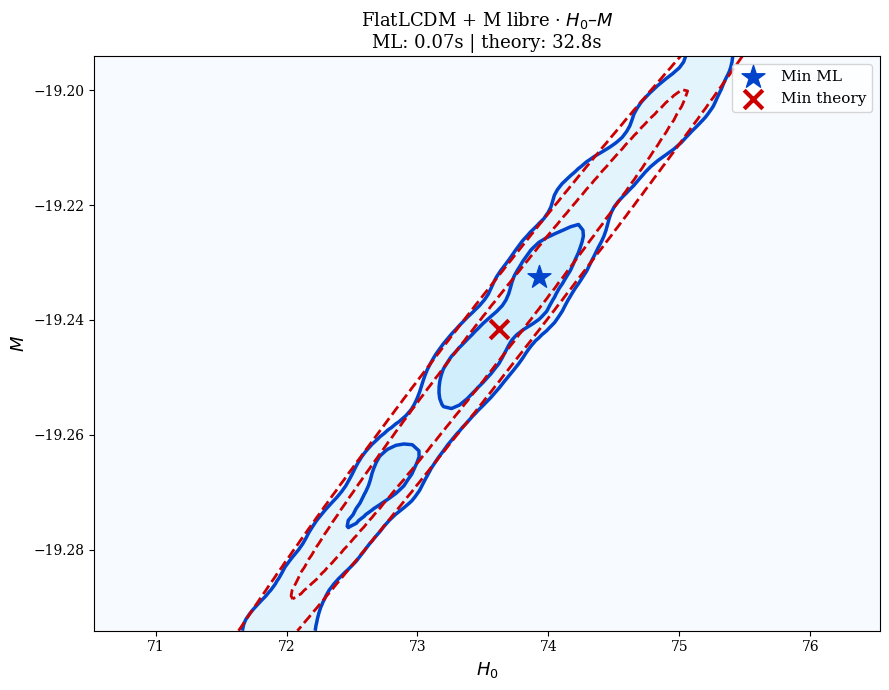

In [56]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.12, REF['Om']+0.12),
    H0=(REF['H0']-3.0, REF['H0']+3.0),
    M=(REF['M']-0.05, REF['M']+0.05),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", M=r"$M$")

for x, y in [('Om','H0'), ('Om','M'), ('H0','M')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"FlatLCDM + M libre · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_beeswarm.png


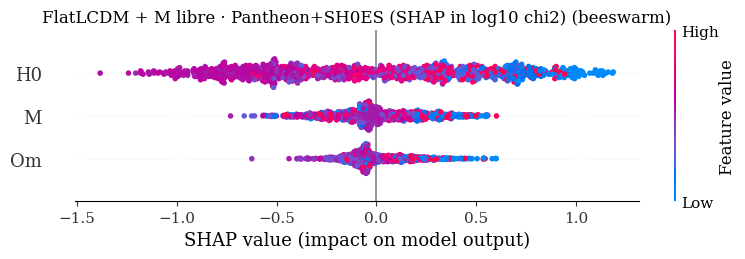

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_bar.png


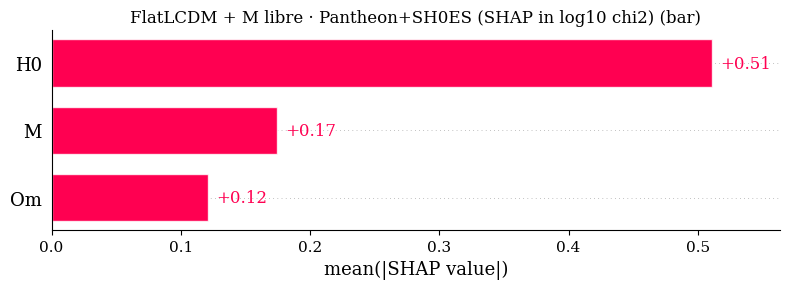

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_waterfall.png


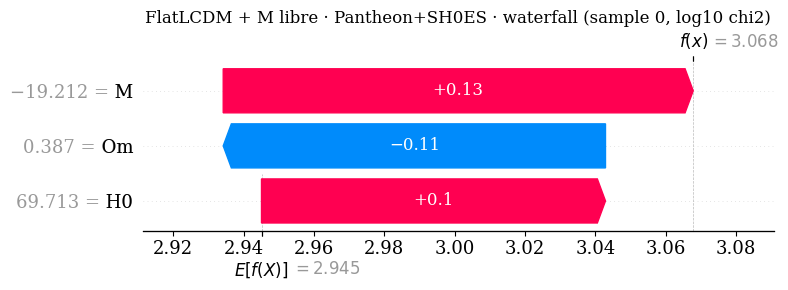

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

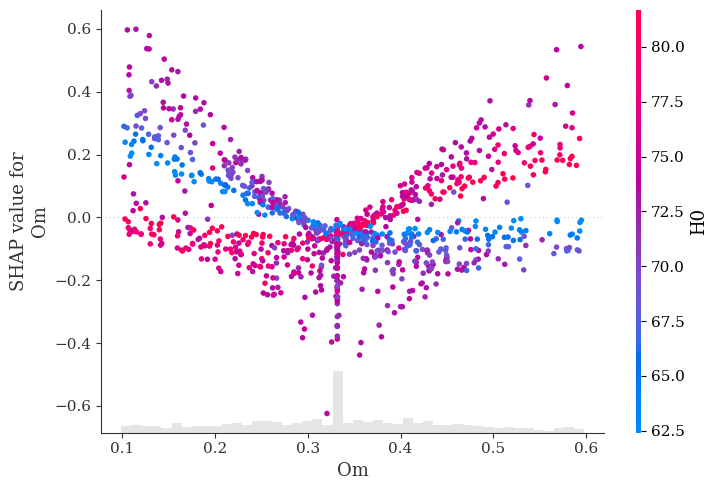

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_H0.png


<Figure size 640x480 with 0 Axes>

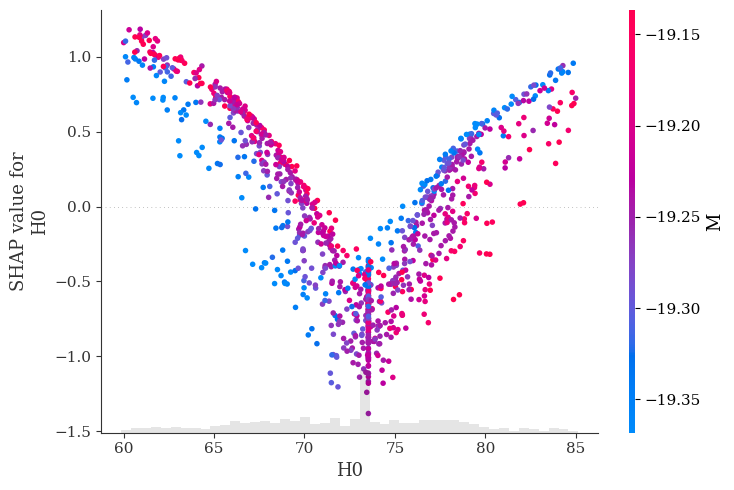

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_M.png


<Figure size 640x480 with 0 Axes>

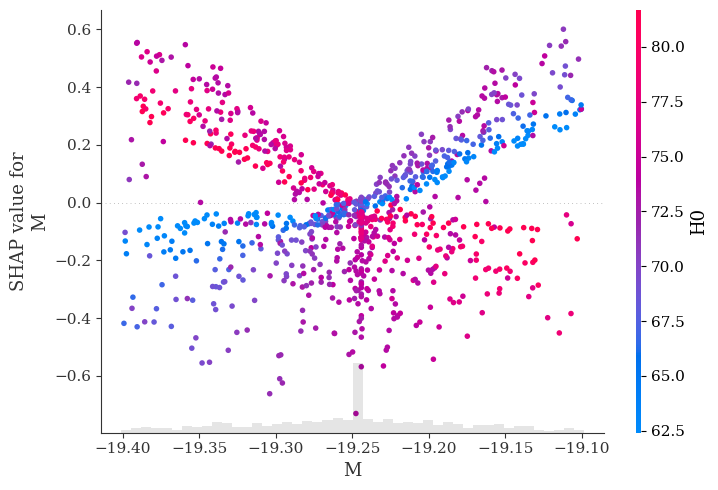

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_M.png')]

In [57]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="FlatLCDM + M libre · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="FlatLCDM + M libre · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-4"></a>1.4 FlatLCDM + SALT2 alpha/beta — 4D (Om, H0, alpha, beta)

**Model:** `FlatLambdaCDM` (Om, H0) with the SALT2 correction applied to m_b:
`m_b_corr += (alpha - alpha0)*x1 - (beta - beta0)*c`.
**Data:** Pantheon+SH0ES with the standard mask, x1/c loaded.
**Cepheids:** **YES**.

alpha (stretch) and beta (color) are SALT2 standardization parameters. The
Pantheon+ paper fiducials are alpha0=0.14, beta0=3.1.


In [58]:
SECTION = "1_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "alpha", "beta"]

# Need x1, c -> include_x1c=True
sne = load_pantheon_plus(apply_mask=True, include_x1c=True)
print(f"Pantheon+ (masked, with x1/c): {len(sne)} SNe")

def chi2_fn(Om, H0, alpha, beta):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M="marginalize",
        alpha=alpha, beta=beta,
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, 0.14, 3.1])))
_m.limits = [(0.1, 0.5), (65, 80), (0.05, 0.25), (2.0, 4.5)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  alpha={REF['alpha']:.4f}  beta={REF['beta']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked, with x1/c): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3326  H0=73.5431  alpha=0.1437  beta=3.0163
chi2(best-fit) = 1449.73


In [59]:
def builder():
    N = 8_000
    rng_alpha, rng_beta = (0.05, 0.25), (2.0, 4.5)
    rng_om, rng_h0 = (0.20, 0.45), (70, 76)
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(alpha=rng_alpha, beta=rng_beta, Om=0.334, H0=73.04, _n=N),
            dict(Om=rng_om, H0=rng_h0, alpha=REF['alpha'], beta=REF['beta'], _n=N),
        ],
        random_box=dict(Om=rng_om, H0=rng_h0, alpha=rng_alpha, beta=rng_beta),
        n_random=30_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_4_dataset.csv)
Evaluating chi2 at 46000 points across 11 cores...
     2000/46000 (  4.3%) | elapsed   85.4s | ETA 1877.7s |     23 pts/s
     4000/46000 (  8.7%) | elapsed  142.7s | ETA 1498.2s |     28 pts/s
     6000/46000 ( 13.0%) | elapsed  209.2s | ETA 1394.9s |     29 pts/s
     8000/46000 ( 17.4%) | elapsed  279.5s | ETA 1327.6s |     29 pts/s
    10000/46000 ( 21.7%) | elapsed  334.5s | ETA 1204.3s |     30 pts/s
    12000/46000 ( 26.1%) | elapsed  390.7s | ETA 1107.1s |     31 pts/s
    14000/46000 ( 30.4%) | elapsed  458.5s | ETA 1048.0s |     31 pts/s
    16000/46000 ( 34.8%) | elapsed  530.0s | ETA  993.8s |     30 pts/s
    18000/46000 ( 39.1%) | elapsed  584.5s | ETA  909.3s |     31 pts/s
    20000/46000 ( 43.5%) | elapsed  646.5s | ETA  840.5s |     31 pts/s
    22000/46000 ( 47.8%) | elapsed  714.9s | ETA  779.9s |     31 pts/s
    24000/46000 ( 52.2%) | elapsed  779.1s | ETA  714.2s |  

  target in shifted-log10: range [0.000, 3.075]
  training: 9.55s | R2=0.99962 | best_iter=484/3000  (early stop, ~84% saved)
  model cached: 1_4_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_learning_curve.png


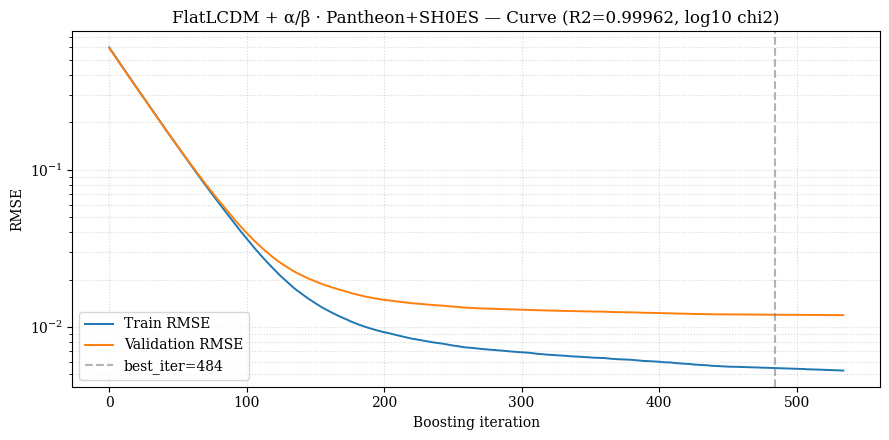

In [60]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM + α/β · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'alpha': 0.14369751011117948, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_H0.png


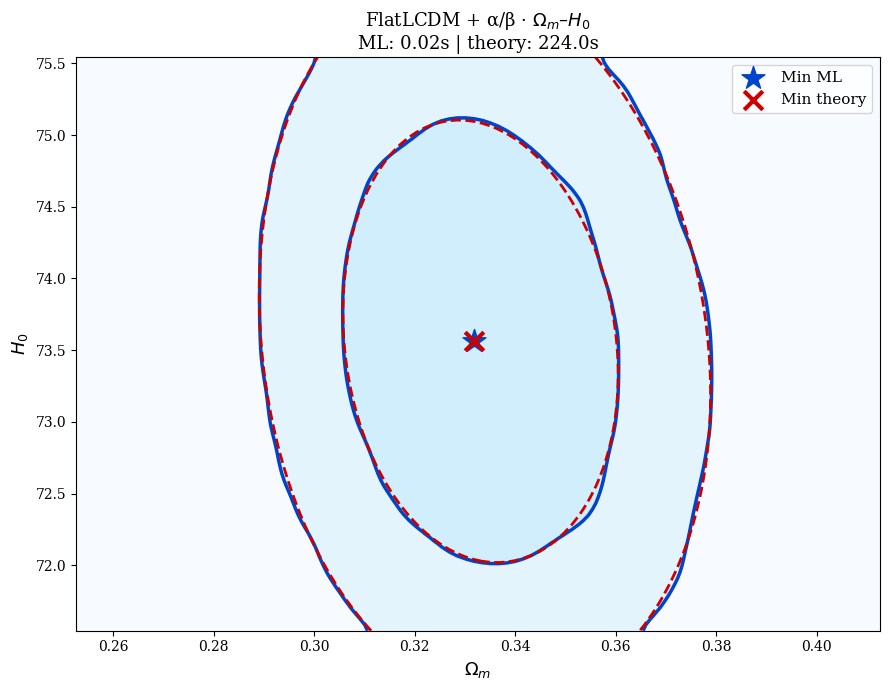

--- $\alpha$ vs $\Omega_m$  ({'H0': 73.54312976586354, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_alpha.png


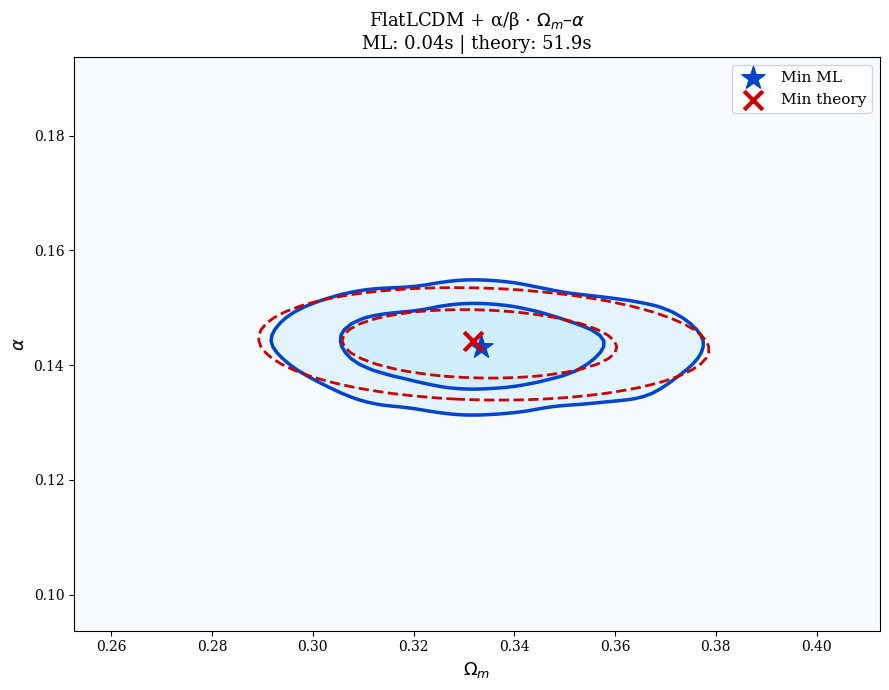

--- $\beta$ vs $\Omega_m$  ({'H0': 73.54312976586354, 'alpha': 0.14369751011117948}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_beta.png


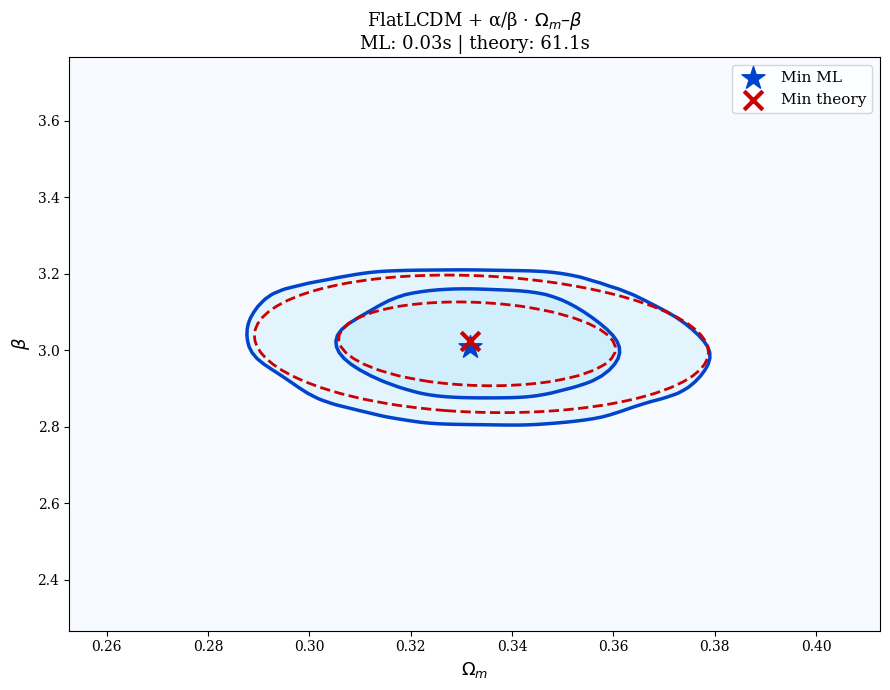

--- $\alpha$ vs $H_0$  ({'Om': 0.332602481238481, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_H0_alpha.png


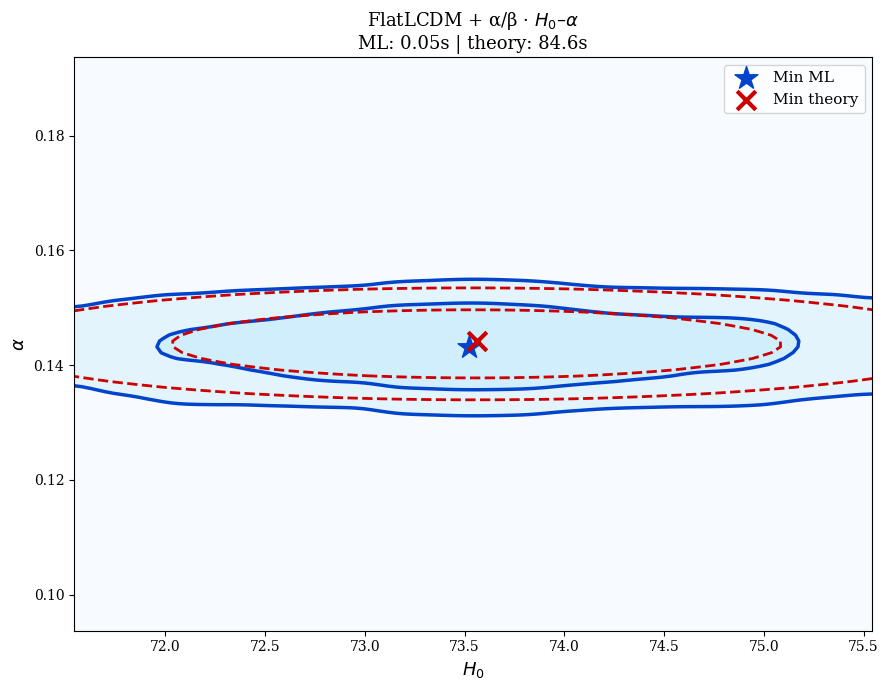

--- $\beta$ vs $H_0$  ({'Om': 0.332602481238481, 'alpha': 0.14369751011117948}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_H0_beta.png


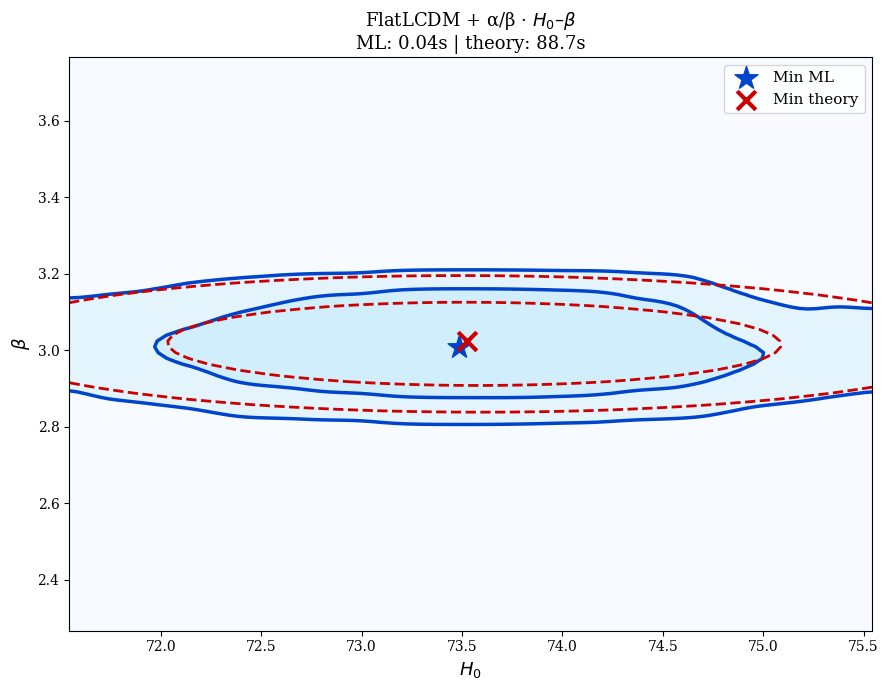

--- $\beta$ vs $\alpha$  ({'Om': 0.332602481238481, 'H0': 73.54312976586354}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_alpha_beta.png


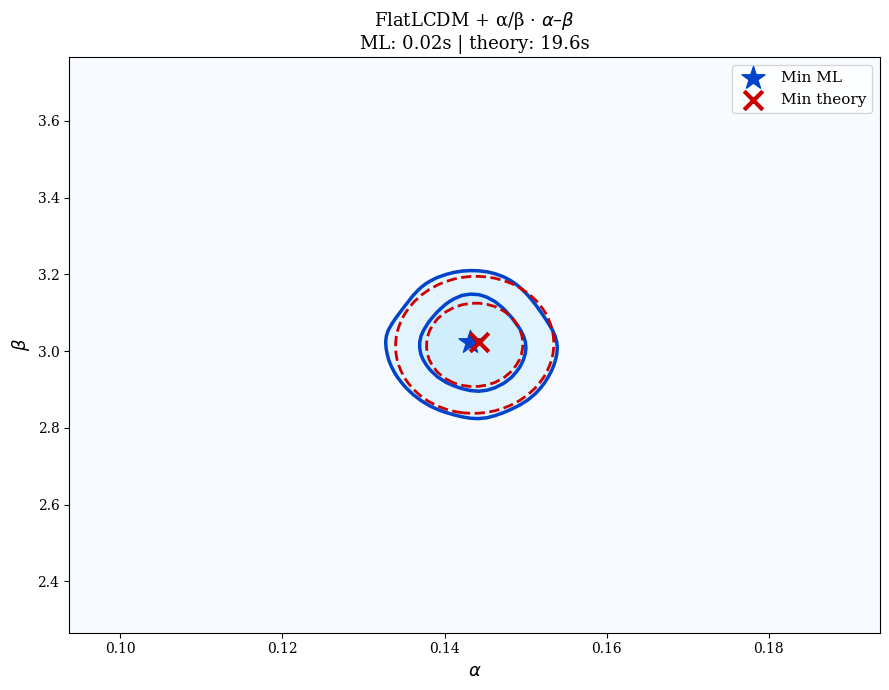

In [61]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.08, REF['Om']+0.08),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    alpha=(REF['alpha']-0.05, REF['alpha']+0.05),
    beta=(REF['beta']-0.75, REF['beta']+0.75),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", alpha=r"$\alpha$", beta=r"$\beta$")

# 6 contours of the 4D corner
for x, y in [('Om','H0'), ('Om','alpha'), ('Om','beta'),
             ('H0','alpha'), ('H0','beta'), ('alpha','beta')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"FlatLCDM + α/β · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beeswarm.png


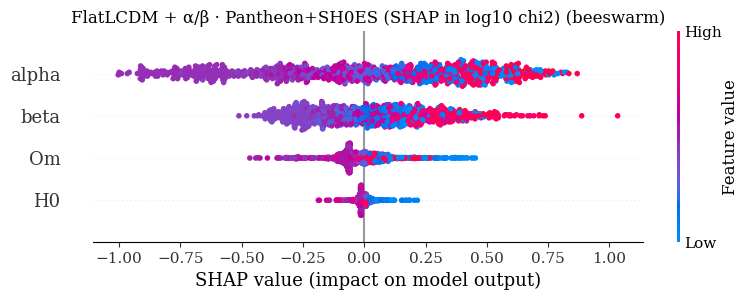

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_bar.png


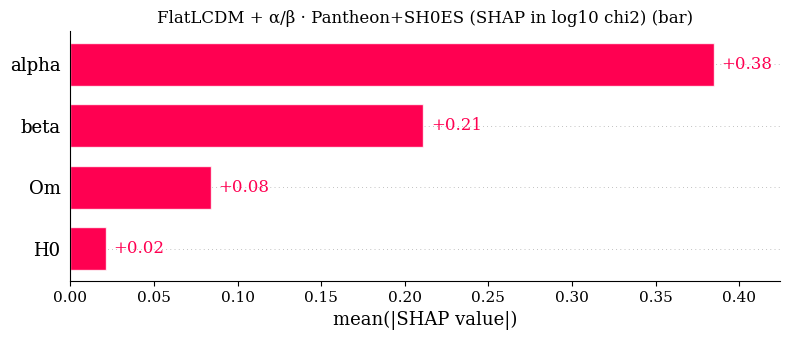

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_waterfall.png


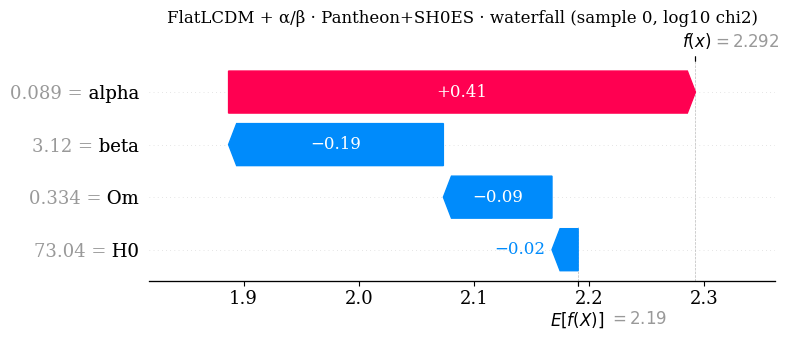

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

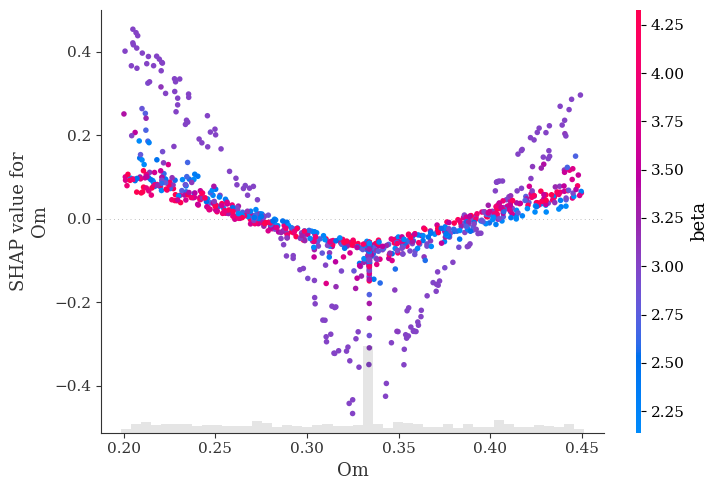

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_H0.png


<Figure size 640x480 with 0 Axes>

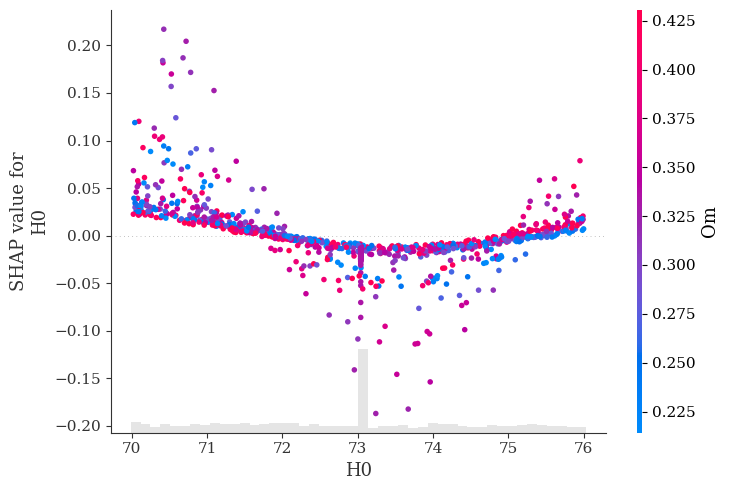

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_alpha.png


<Figure size 640x480 with 0 Axes>

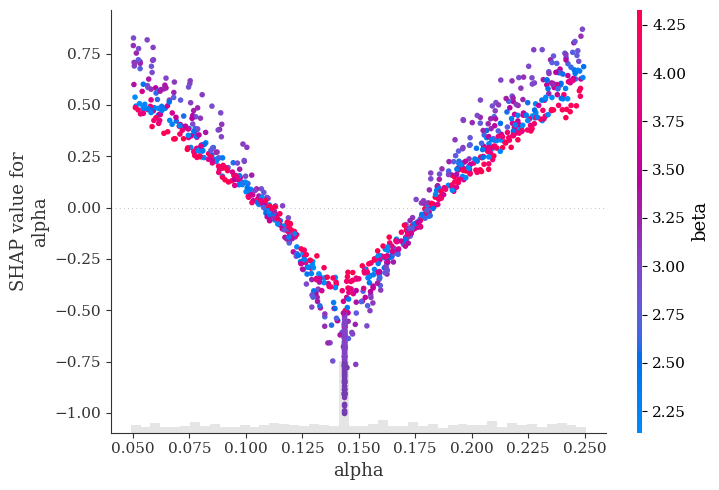

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beta.png


<Figure size 640x480 with 0 Axes>

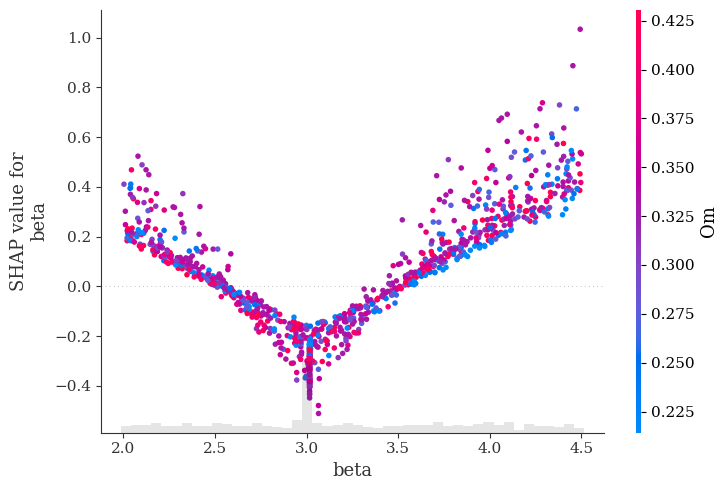

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_alpha.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beta.png')]

In [62]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="FlatLCDM + α/β · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="FlatLCDM + α/β · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-5"></a>1.5 wCDM — 3D (Om, H0, w) with Cepheids

**Model:** `FlatwCDM` (Om, H0, w); dark energy with constant equation of state.
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

First model with w free — LambdaCDM corresponds to w = -1.


In [63]:
SECTION = "1_5"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (masked): {len(sne)} SNe")

def chi2_fn(Om, H0, w):
    return chi2_sne(
        sne, model="FlatwCDM",
        Om=Om, H0=H0, w0=w,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, -1.0])))
_m.limits = [(0.1, 0.5), (65, 80), (-1.8, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2965  H0=73.4374  w=-0.9119
chi2(best-fit) = 1451.69


In [64]:
def builder():
    N = 7_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=(0.0, 0.6), w=(-1.8, -0.2), H0=REF['H0'], _n=N),
            dict(Om=(0.0, 0.6), H0=(60, 85),    w=REF['w'],   _n=N),
            dict(H0=(60, 85),   w=(-1.8, -0.2), Om=REF['Om'], _n=N),
        ],
        random_box=dict(Om=(0.0, 0.65), H0=(55, 90), w=(-2.2, -0.1)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_5_dataset.csv)
Evaluating chi2 at 41000 points across 11 cores...
     2000/41000 (  4.9%) | elapsed   76.2s | ETA 1486.4s |     26 pts/s
     4000/41000 (  9.8%) | elapsed  145.4s | ETA 1344.9s |     28 pts/s
     6000/41000 ( 14.6%) | elapsed  213.1s | ETA 1243.0s |     28 pts/s
     8000/41000 ( 19.5%) | elapsed  281.5s | ETA 1161.0s |     28 pts/s
    10000/41000 ( 24.4%) | elapsed  344.6s | ETA 1068.2s |     29 pts/s
    12000/41000 ( 29.3%) | elapsed  396.3s | ETA  957.7s |     30 pts/s
    14000/41000 ( 34.1%) | elapsed  462.1s | ETA  891.2s |     30 pts/s
    16000/41000 ( 39.0%) | elapsed  529.7s | ETA  827.7s |     30 pts/s
    18000/41000 ( 43.9%) | elapsed  594.4s | ETA  759.5s |     30 pts/s
    20000/41000 ( 48.8%) | elapsed  652.1s | ETA  684.7s |     31 pts/s
    22000/41000 ( 53.7%) | elapsed  717.3s | ETA  619.5s |     31 pts/s
    24000/41000 ( 58.5%) | elapsed  777.3s | ETA  550.6s |  

  target in shifted-log10: range [0.000, 3.971]
  training: 17.93s | R2=0.99892 | best_iter=852/3000  (early stop, ~72% saved)
  model cached: 1_5_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_learning_curve.png


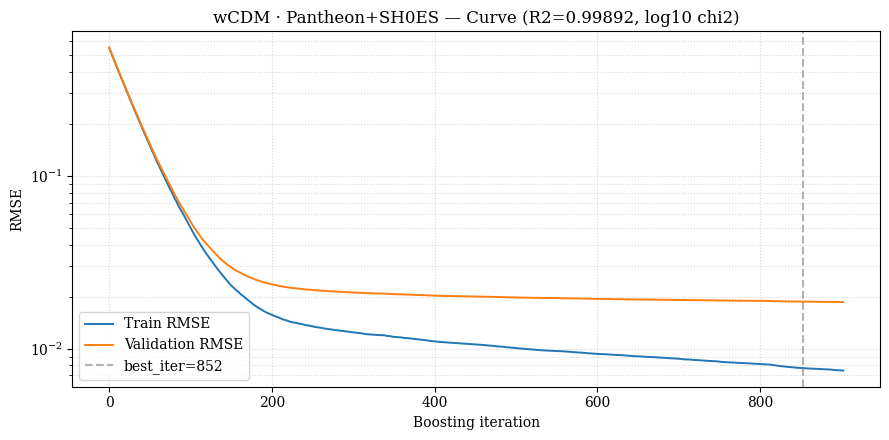

In [65]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"wCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w': -0.9118766319456396}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_Om_H0.png


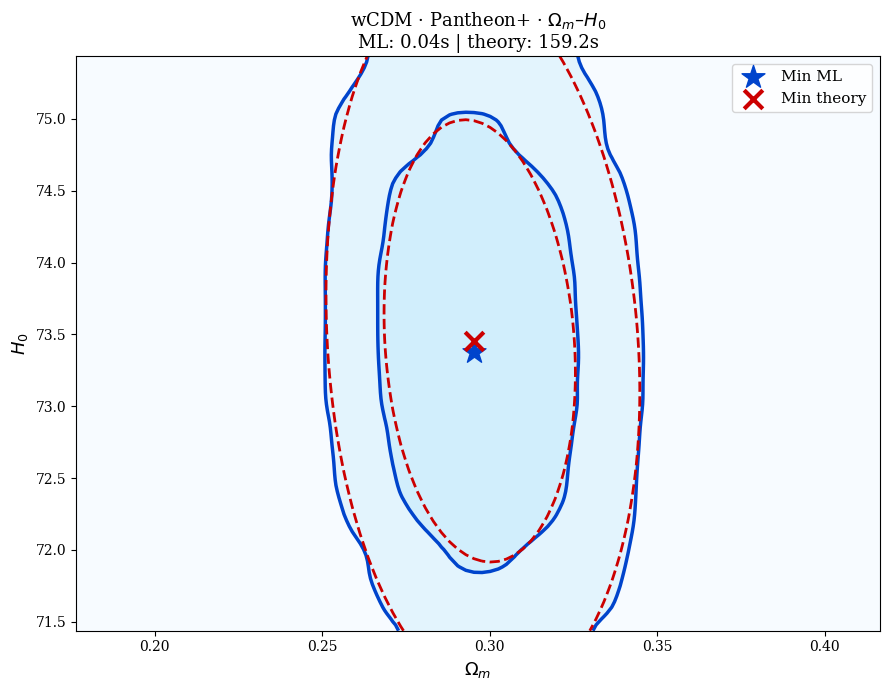

--- $w$ vs $\Omega_m$  ({'H0': 73.43742985304021}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_Om_w.png


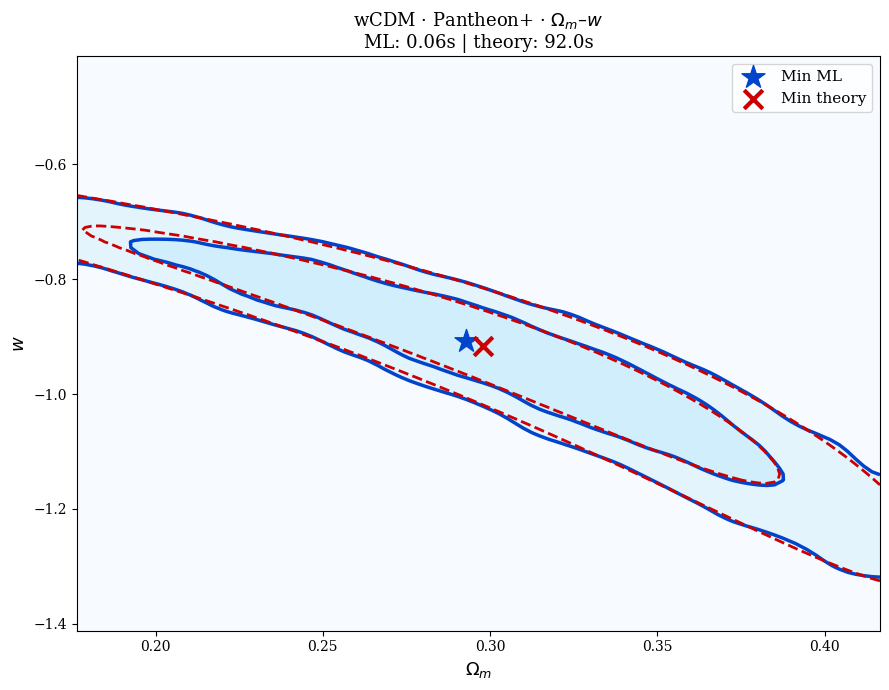

--- $w$ vs $H_0$  ({'Om': 0.2964935486244961}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_H0_w.png


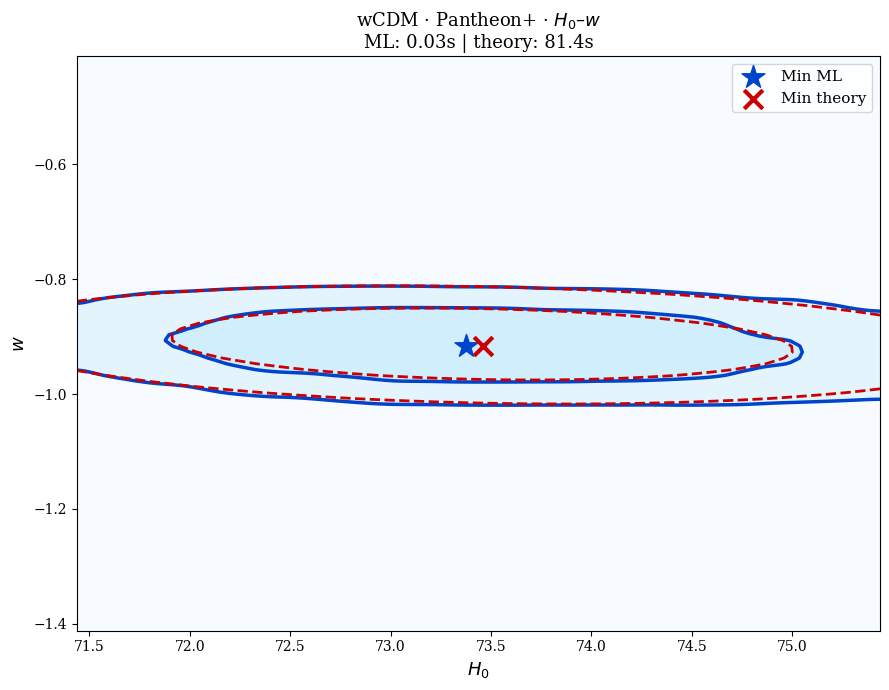

In [66]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.12, REF['Om']+0.12),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    w=(REF['w']-0.5, REF['w']+0.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w=r"$w$")

for x, y in [('Om','H0'), ('Om','w'), ('H0','w')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"wCDM · Pantheon+ · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_beeswarm.png


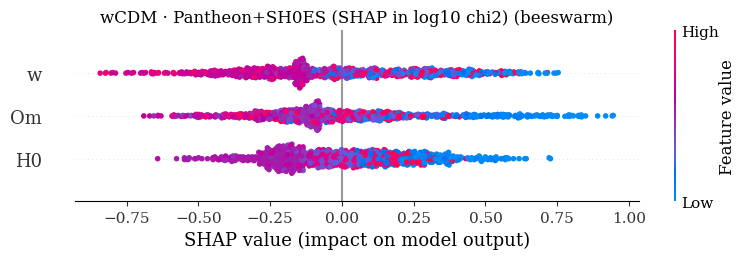

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_bar.png


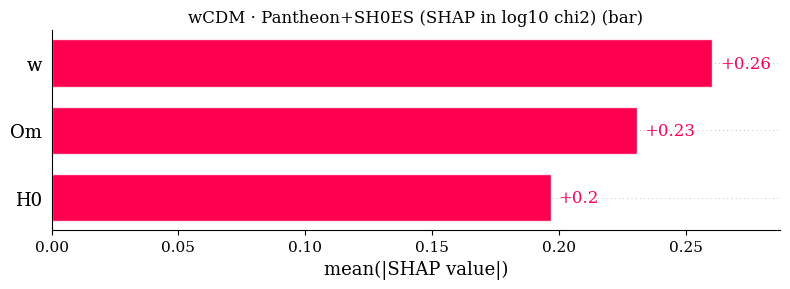

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_waterfall.png


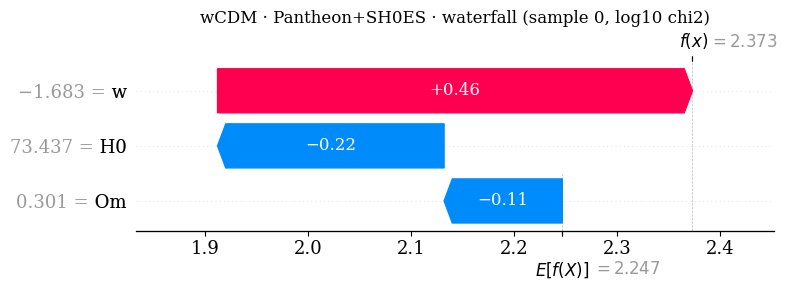

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_Om.png


<Figure size 640x480 with 0 Axes>

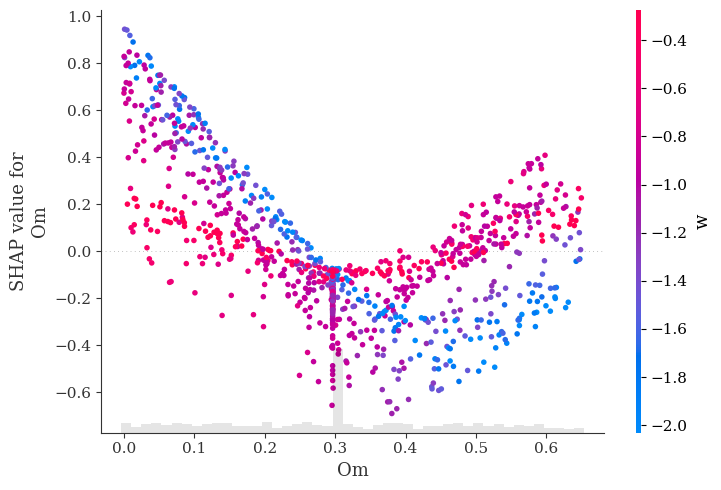

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_H0.png


<Figure size 640x480 with 0 Axes>

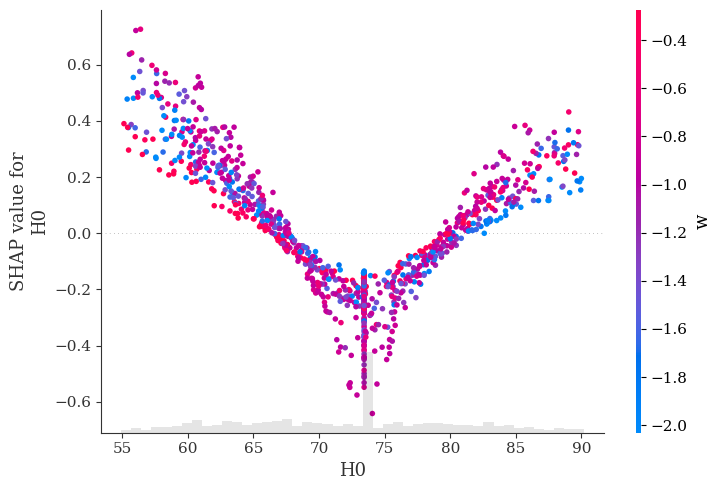

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_w.png


<Figure size 640x480 with 0 Axes>

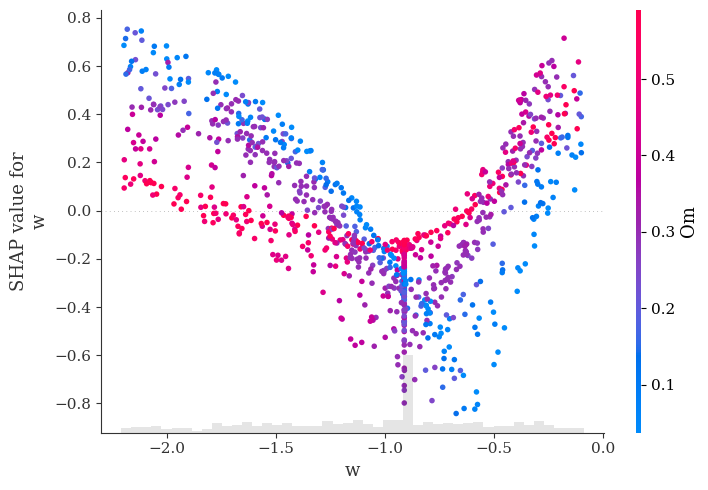

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_w.png')]

In [67]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="wCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="wCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-6"></a>1.6 w0waCDM with SH0ES — 4D (Om, H0, w0, wa)

**Model:** `Flatw0waCDM` with the CPL parametrization w(z) = w0 + wa*z/(1+z).
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

First 4D scenario. wa characterizes the evolution of dark energy
(LambdaCDM corresponds to w0 = -1, wa = 0).


In [ ]:
SECTION = "1_6"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ with SH0ES: {len(sne)} SNe, calibradores={sne.is_calib.sum()}")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# SN-only w0waCDM: wa no está restringida; se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit ...")
_m = Minuit(lambda Om, H0, w0, wa: chi2_fn(Om=Om, H0=H0, w0=w0, wa=wa), Om=0.3, H0=73.0, w0=-1.0, wa=0.0)
_m.limits = [(0.15, 0.45), (65, 80), (-2.0, 0.0), (-4,1)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=float(_m.values['wa'])),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), float(_m.values['wa'])]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ with SH0ES: 1657 SNe, calibradores=77
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.3074  H0=73.4258  w0=-0.9201  wa=-0.1102
chi2(best-fit) = 1451.69


In [72]:
def builder():
    N = 8_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.2), wa=(-3.0, 2.0), Om=REF['Om'], H0=REF['H0'], _n=N),
            dict(Om=(0.0, 0.5), w0=(-2.0, 0.2), wa=REF['wa'], H0=REF['H0'], _n=N),
            dict(H0=(65, 80), w0=(-2.0, 0.2), wa=REF['wa'], Om=REF['Om'], _n=N),
        ],
        random_box=dict(Om=(0.2, 0.6), H0=(60, 85), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_6_dataset.csv)
Evaluating chi2 at 42000 points across 11 cores...
     2000/42000 (  4.8%) | elapsed  149.4s | ETA 2988.5s |     13 pts/s
     4000/42000 (  9.5%) | elapsed  258.8s | ETA 2458.4s |     15 pts/s
     6000/42000 ( 14.3%) | elapsed  369.3s | ETA 2215.8s |     16 pts/s
     8000/42000 ( 19.0%) | elapsed  478.0s | ETA 2031.7s |     17 pts/s
    10000/42000 ( 23.8%) | elapsed  571.9s | ETA 1830.0s |     17 pts/s
    12000/42000 ( 28.6%) | elapsed  675.9s | ETA 1689.7s |     18 pts/s
    14000/42000 ( 33.3%) | elapsed  772.5s | ETA 1545.0s |     18 pts/s
    16000/42000 ( 38.1%) | elapsed  884.3s | ETA 1437.0s |     18 pts/s
    18000/42000 ( 42.9%) | elapsed  992.1s | ETA 1322.8s |     18 pts/s
    20000/42000 ( 47.6%) | elapsed 1097.9s | ETA 1207.7s |     18 pts/s
    22000/42000 ( 52.4%) | elapsed 1203.7s | ETA 1094.3s |     18 pts/s
    24000/42000 ( 57.1%) | elapsed 1297.4s | ETA  973.0s |  

  target in shifted-log10: range [0.000, 3.849]
  training: 175.95s | R2=0.99605 | best_iter=866/3000  (early stop, ~71% saved)
  model cached: 1_6_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_learning_curve.png


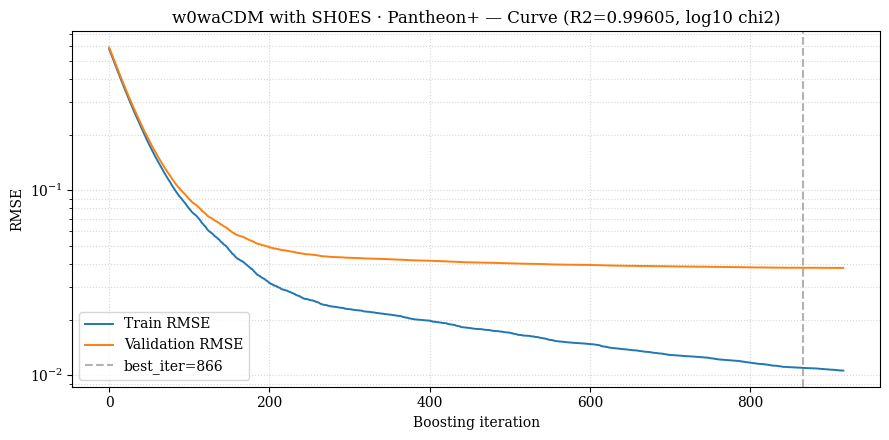

In [73]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"w0waCDM with SH0ES · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.9200984560380409, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_H0.png


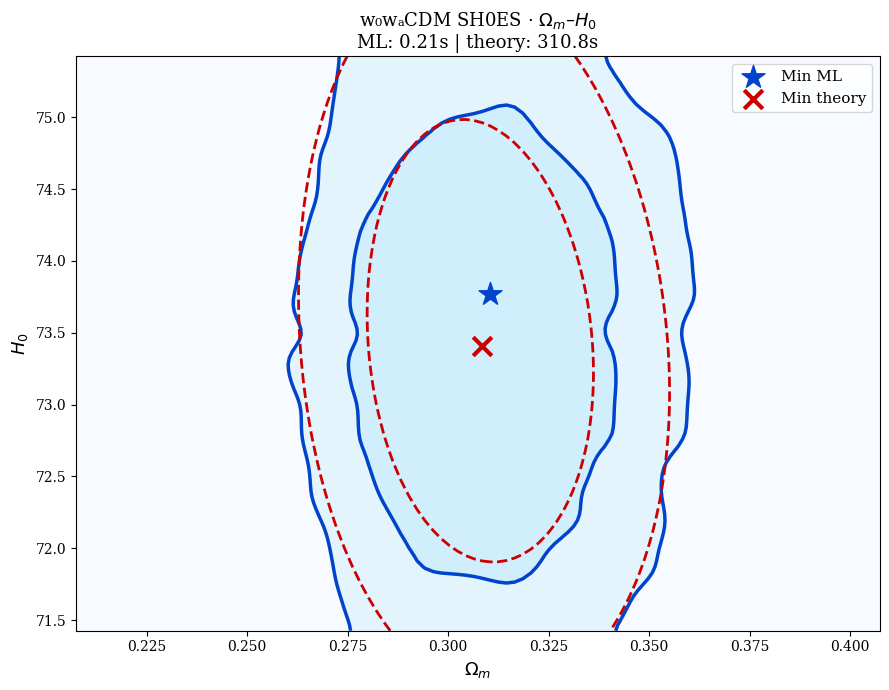

--- $w_0$ vs $\Omega_m$  ({'H0': 73.42578014942657, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_w0.png


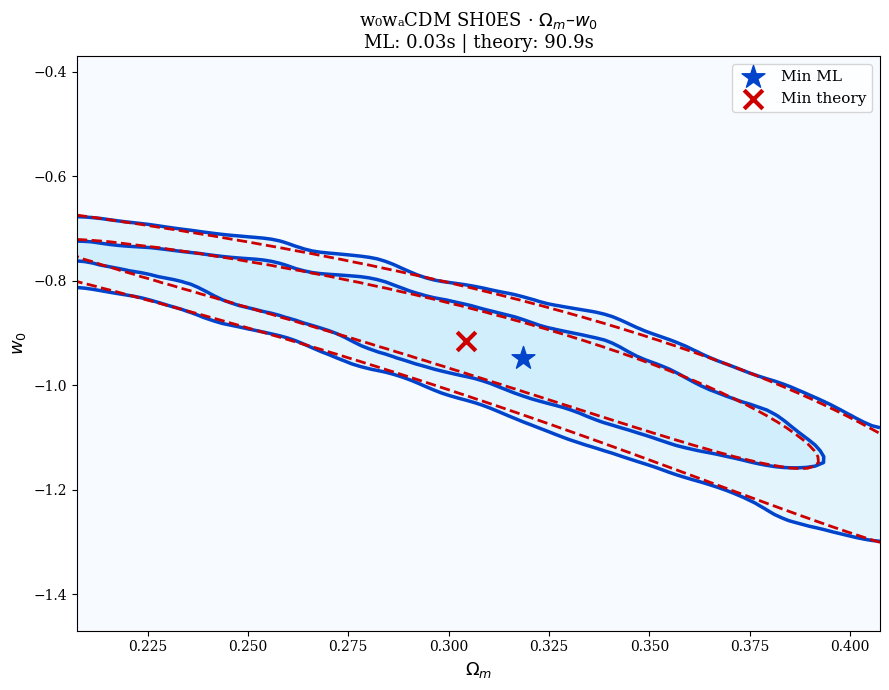

--- $w_a$ vs $\Omega_m$  ({'H0': 73.42578014942657, 'w0': -0.9200984560380409}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_wa.png


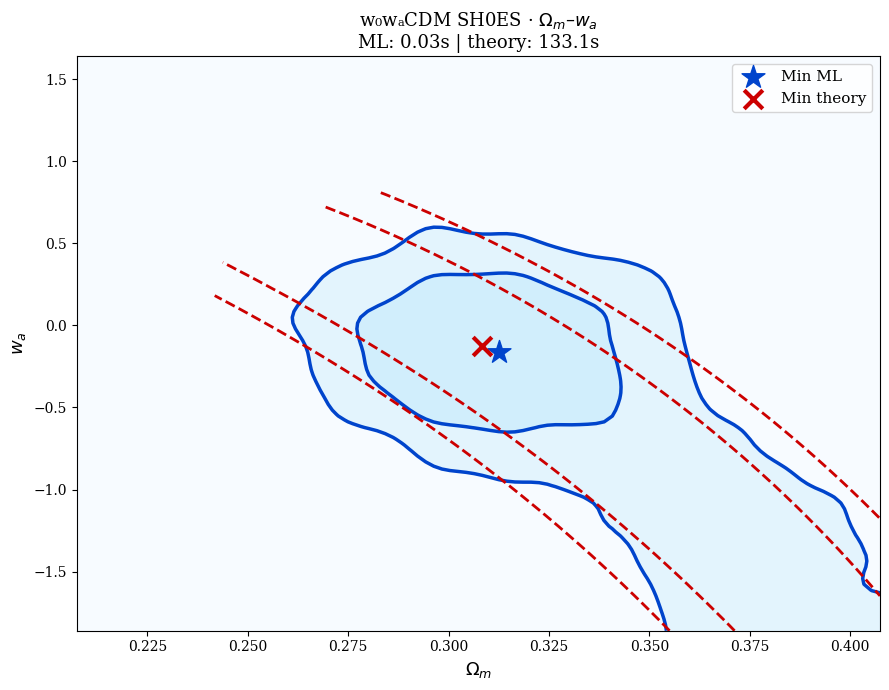

--- $w_0$ vs $H_0$  ({'Om': 0.3074145901926835, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_H0_w0.png


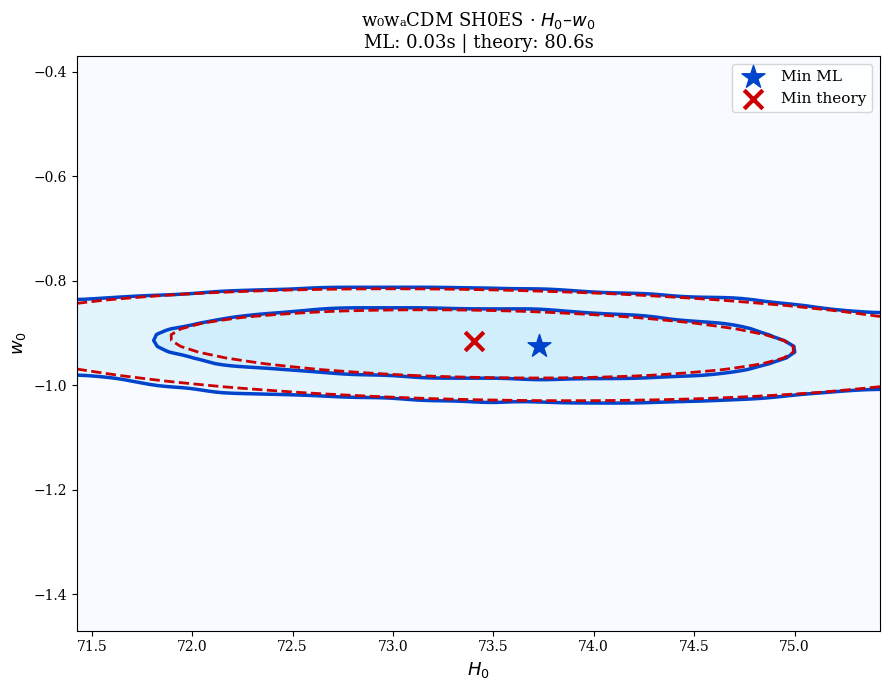

--- $w_a$ vs $H_0$  ({'Om': 0.3074145901926835, 'w0': -0.9200984560380409}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_H0_wa.png


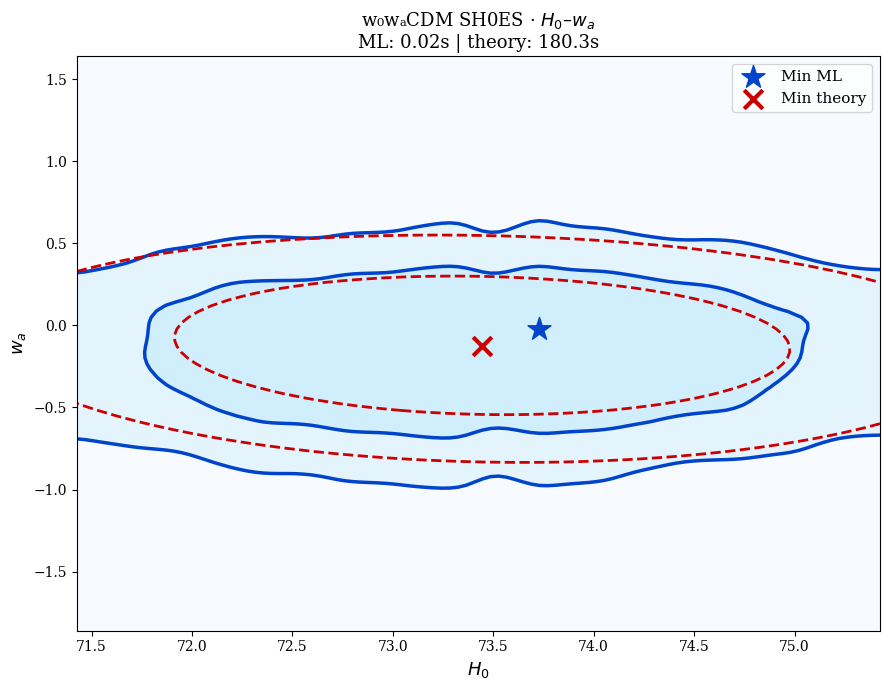

--- $w_a$ vs $w_0$  ({'Om': 0.3074145901926835, 'H0': 73.42578014942657}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_w0_wa.png


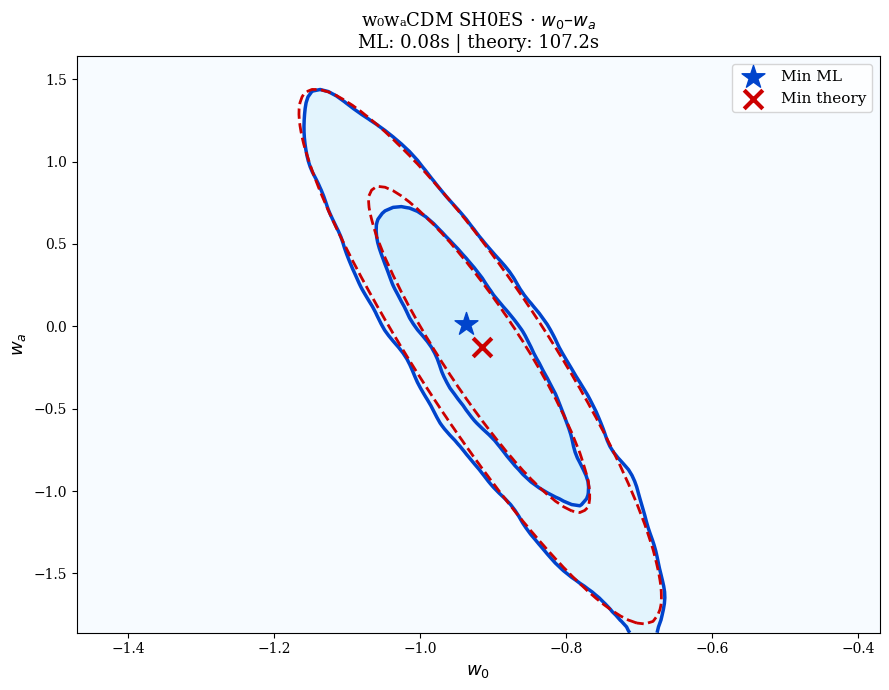

In [74]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.10, REF['Om']+0.10),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    w0=(REF['w0']-0.55, REF['w0']+0.55),
    wa=(REF['wa']-1.75, REF['wa']+1.75),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w₀wₐCDM SH0ES · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_beeswarm.png


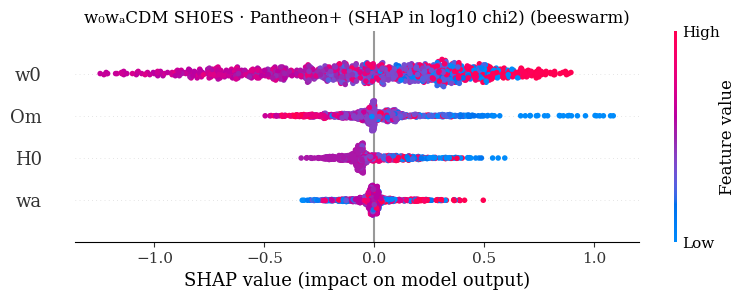

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_bar.png


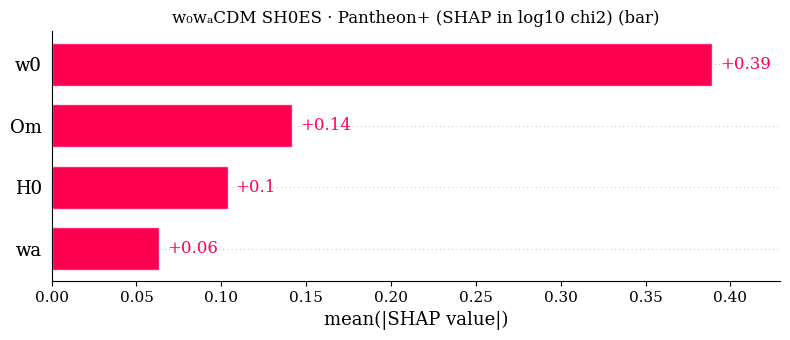

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_waterfall.png


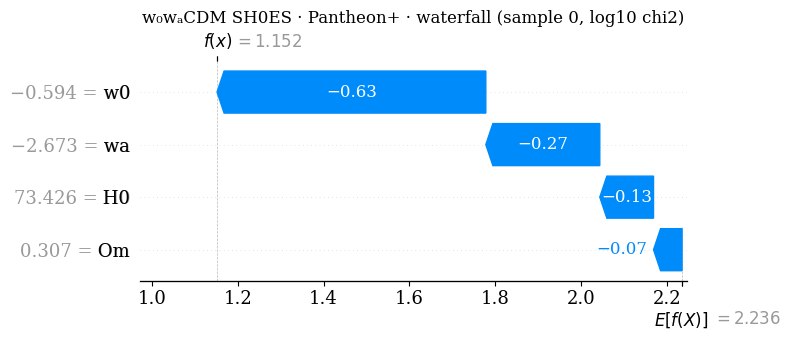

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_Om.png


<Figure size 640x480 with 0 Axes>

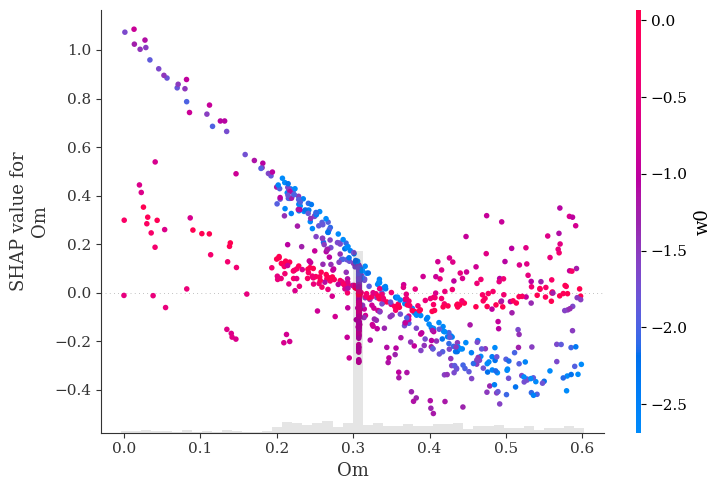

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_H0.png


<Figure size 640x480 with 0 Axes>

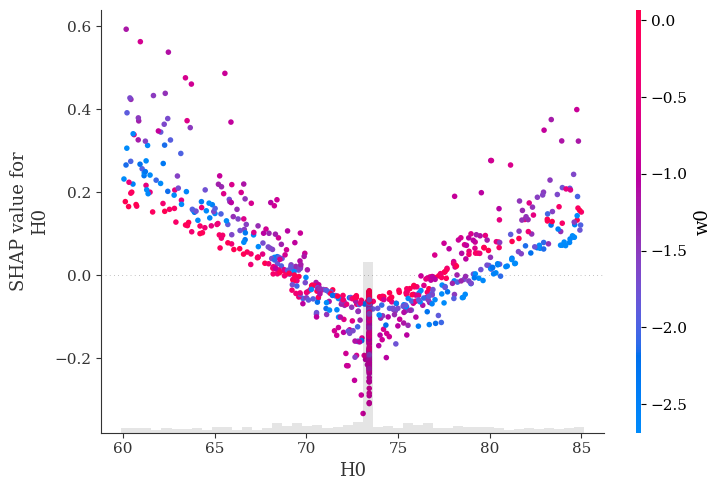

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_w0.png


<Figure size 640x480 with 0 Axes>

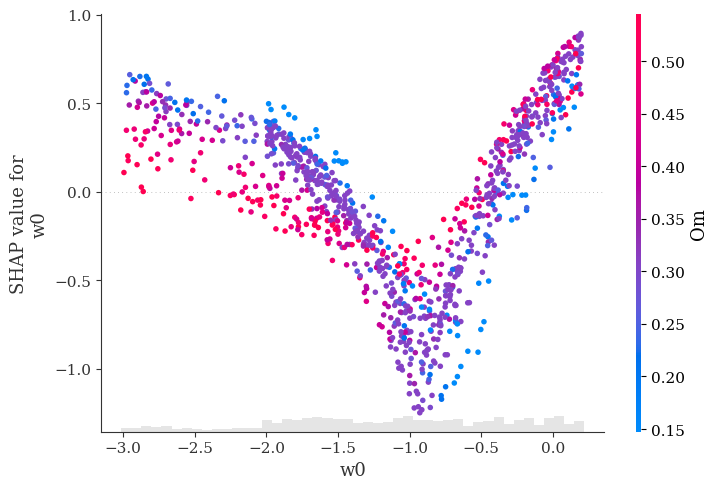

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_wa.png


<Figure size 640x480 with 0 Axes>

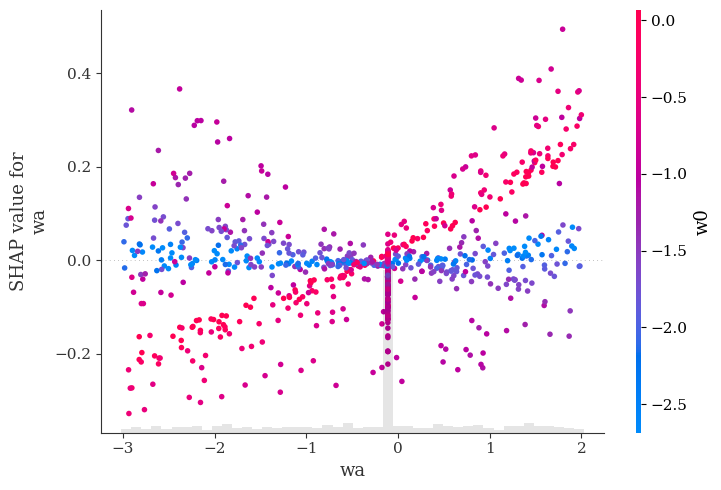

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_wa.png')]

In [75]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="w₀wₐCDM SH0ES · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="w₀wₐCDM SH0ES · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-7"></a>1.7 w0waCDM WITHOUT SH0ES — 4D (Om, H0, w0, wa)

**Model:** `Flatw0waCDM` (Om, H0, w0, wa) — same as 1.6.
**Data:** Pantheon+ with the z>0.01 mask but **without OR-ing the calibrators**.
**Cepheids:** **NO** (`use_cepheid_calibrators=False`, `keep_calibrators=False`).

Without the SH0ES anchor, H0 becomes poorly constrained.


In [32]:
SECTION = "1_7"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

# No SH0ES: apply mask z>0.01 without OR-ing with is_calib (drop Cepheids)
sne = load_pantheon_plus(apply_mask=True, keep_calibrators=False)
print(f"Pantheon+ without SH0ES: {len(sne)} SNe (calibrators excluded)")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=False,
    )

# SN-only w0waCDM: wa no está restringida; se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, H0, w0: chi2_fn(Om=Om, H0=H0, w0=w0, wa=0.0), Om=0.3, H0=70.0, w0=-1.0)
_m.limits = [(0.15, 0.5), (60, 85), (-2.0, 0.0)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ without SH0ES: 1590 SNe (calibrators excluded)
Locating the global minimum with Nelder-Mead...
Auto-detected best-fit:  Om=0.1763  H0=60.0000  w0=-0.7980  wa=0.5720
chi2(best-fit) = 1402.40


In [33]:
def builder():
    N = 8_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.2), wa=(-3.0, 2.0), Om=REF['Om'], H0=REF['H0'], _n=N),
            dict(Om=(0.0, 0.5), w0=(-2.0, 0.2), wa=REF['wa'], H0=REF['H0'], _n=N),
            dict(H0=(65, 80), w0=(-2.0, 0.2), wa=REF['wa'], Om=REF['Om'], _n=N),
        ],
        random_box=dict(Om=(0.2, 0.6), H0=(60, 85), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_7_dataset.csv)
Evaluating chi2 at 42000 points across 11 cores...
     2000/42000 (  4.8%) | elapsed   72.2s | ETA 1444.9s |     28 pts/s
     4000/42000 (  9.5%) | elapsed  137.5s | ETA 1306.4s |     29 pts/s
     6000/42000 ( 14.3%) | elapsed  202.8s | ETA 1216.8s |     30 pts/s
     8000/42000 ( 19.0%) | elapsed  270.9s | ETA 1151.3s |     30 pts/s
    10000/42000 ( 23.8%) | elapsed  336.4s | ETA 1076.6s |     30 pts/s
    12000/42000 ( 28.6%) | elapsed  381.0s | ETA  952.4s |     31 pts/s
    14000/42000 ( 33.3%) | elapsed  450.8s | ETA  901.6s |     31 pts/s
    16000/42000 ( 38.1%) | elapsed  519.4s | ETA  844.0s |     31 pts/s
    18000/42000 ( 42.9%) | elapsed  585.7s | ETA  781.0s |     31 pts/s
    20000/42000 ( 47.6%) | elapsed  653.5s | ETA  718.9s |     31 pts/s
    22000/42000 ( 52.4%) | elapsed  702.9s | ETA  639.0s |     31 pts/s
    24000/42000 ( 57.1%) | elapsed  770.7s | ETA  578.0s |  

  target in shifted-log10: range [0.000, 3.746]
  training: 13.04s | R2=0.99703 | best_iter=595/3000  (early stop, ~80% saved)
  model cached: 1_7_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_learning_curve.png


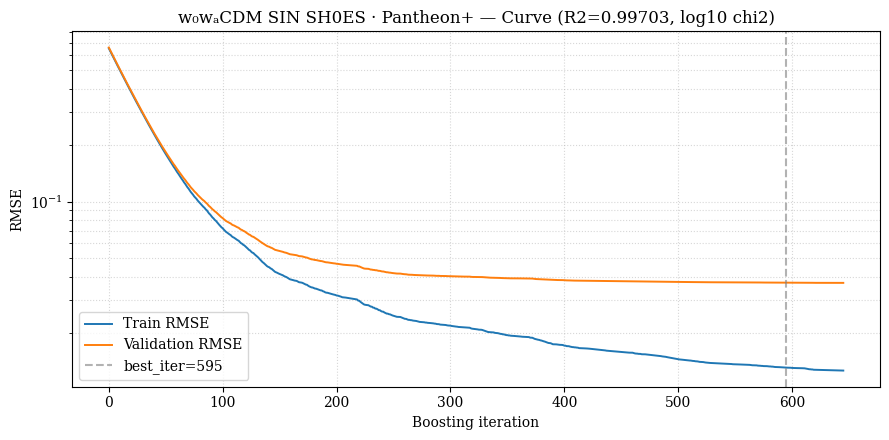

In [34]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM SIN SH0ES · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.798010553979084, 'wa': 0.5720339071862509}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_H0.png


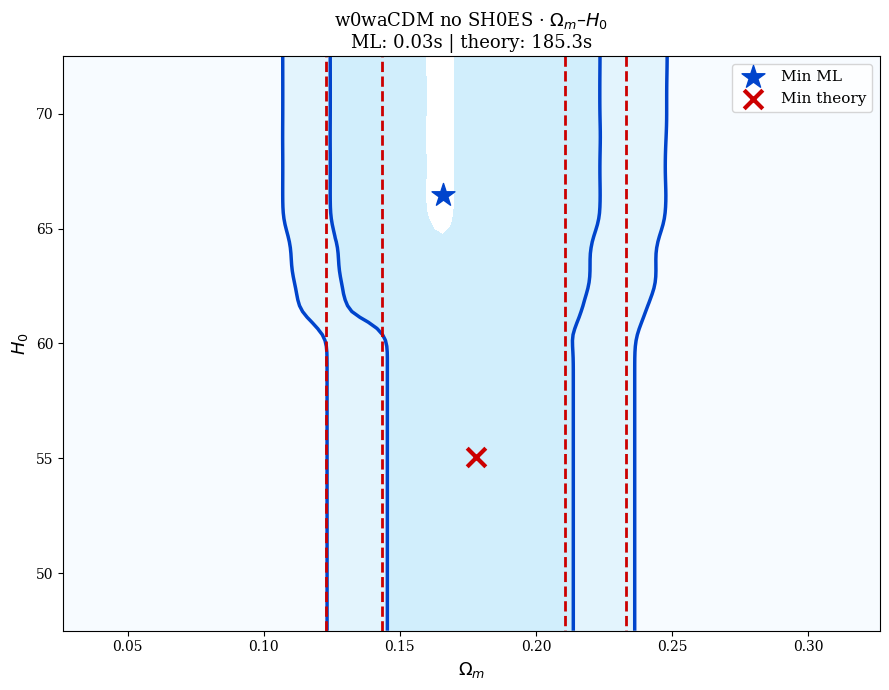

--- $w_0$ vs $\Omega_m$  ({'H0': 60.0, 'wa': 0.5720339071862509}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_w0.png


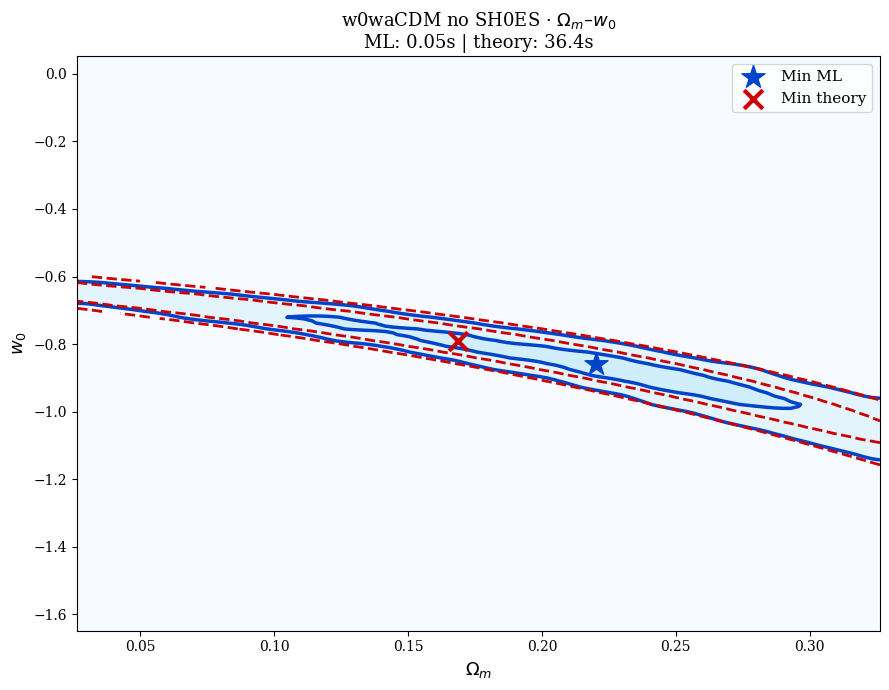

--- $w_a$ vs $\Omega_m$  ({'H0': 60.0, 'w0': -0.798010553979084}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_wa.png


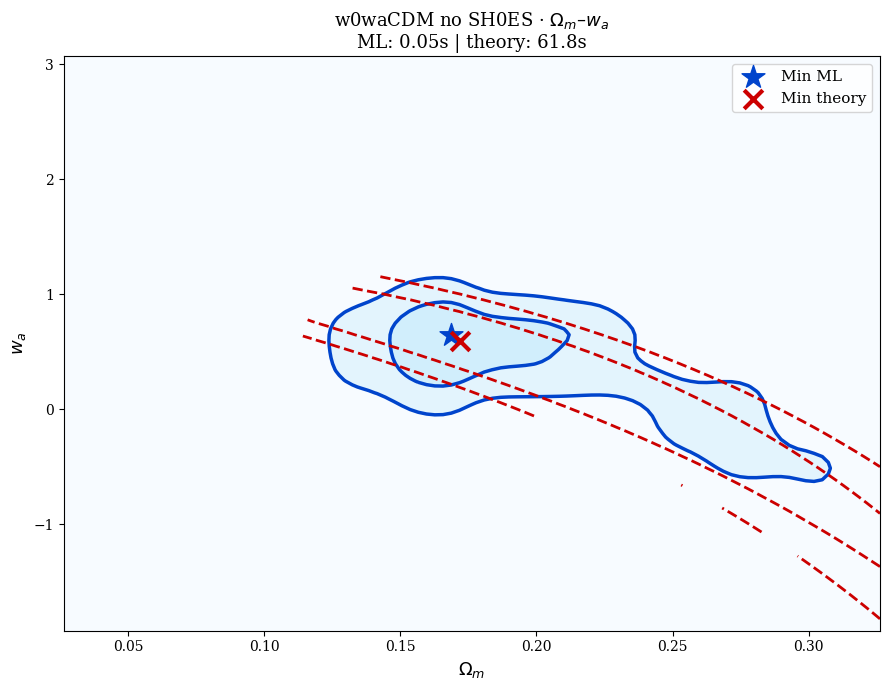

--- $w_0$ vs $H_0$  ({'Om': 0.17625747406495976, 'wa': 0.5720339071862509}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_H0_w0.png


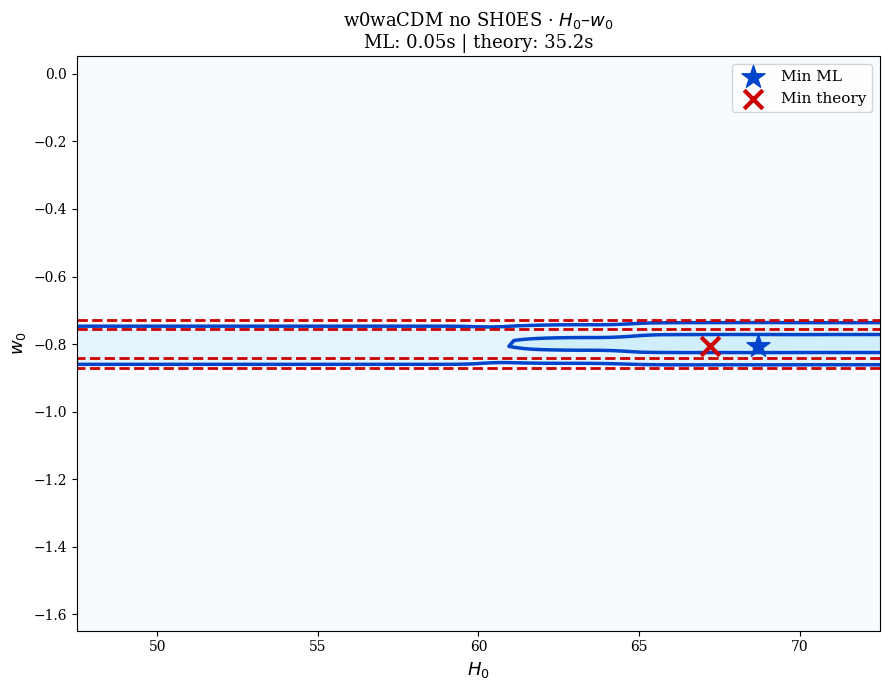

--- $w_a$ vs $H_0$  ({'Om': 0.17625747406495976, 'w0': -0.798010553979084}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_H0_wa.png


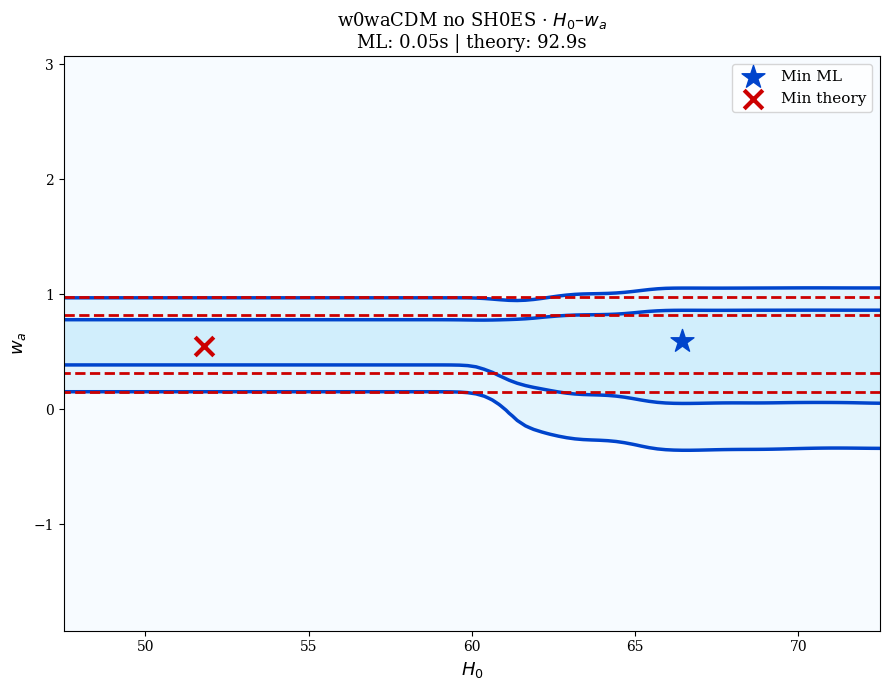

--- $w_a$ vs $w_0$  ({'Om': 0.17625747406495976, 'H0': 60.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_w0_wa.png


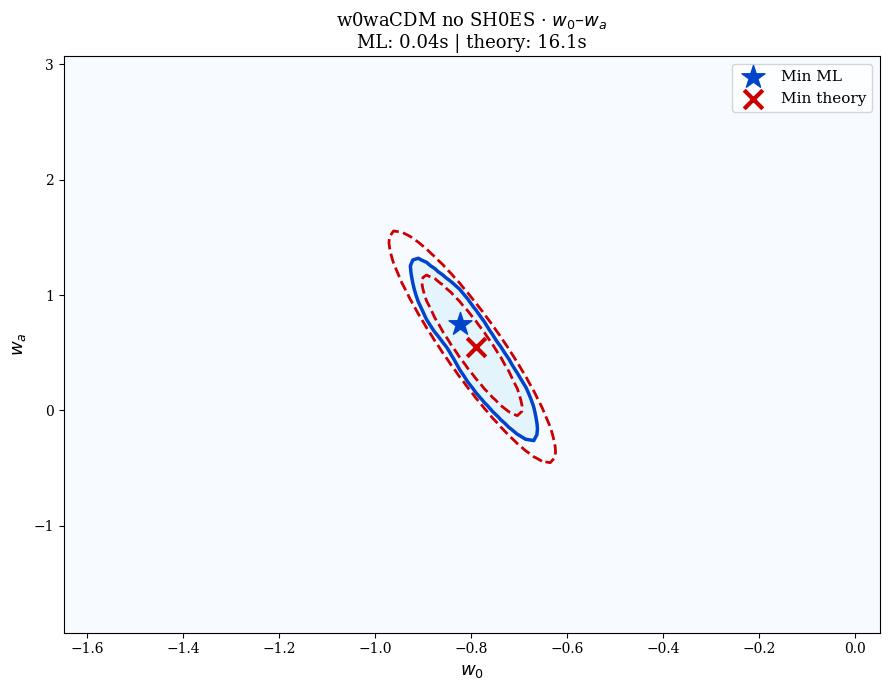

In [35]:
# Without SH0ES, contours along H0 are very wide.
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.15, REF['Om']+0.15),
    H0=(REF['H0']-12.5, REF['H0']+12.5),
    w0=(REF['w0']-0.85, REF['w0']+0.85),
    wa=(REF['wa']-2.5, REF['wa']+2.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w0waCDM no SH0ES · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_beeswarm.png


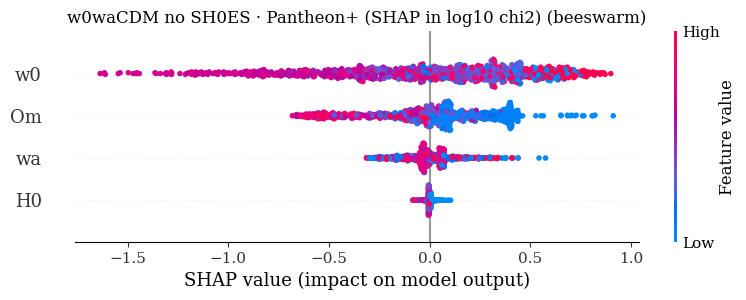

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_bar.png


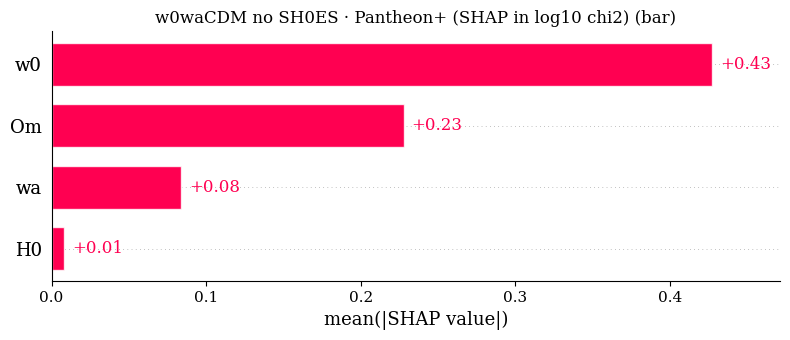

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_waterfall.png


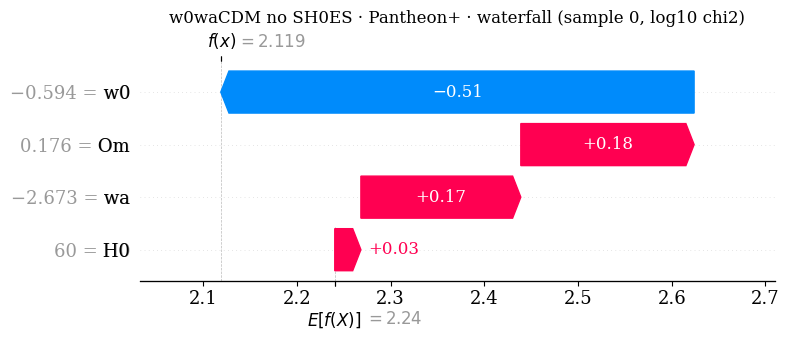

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_Om.png


<Figure size 640x480 with 0 Axes>

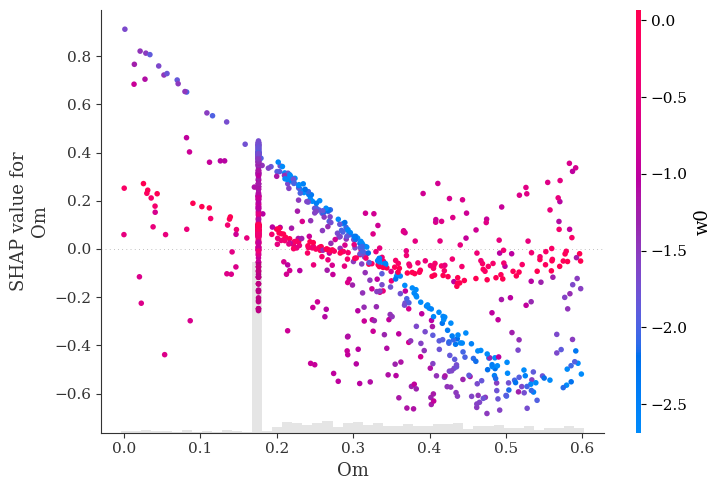

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_H0.png


<Figure size 640x480 with 0 Axes>

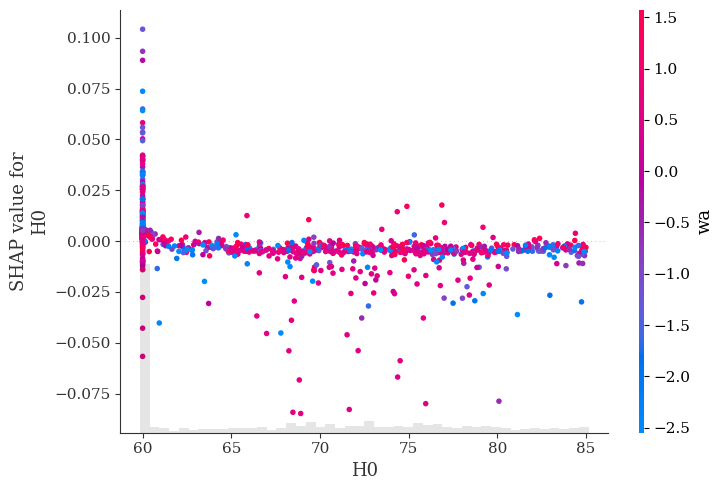

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_w0.png


<Figure size 640x480 with 0 Axes>

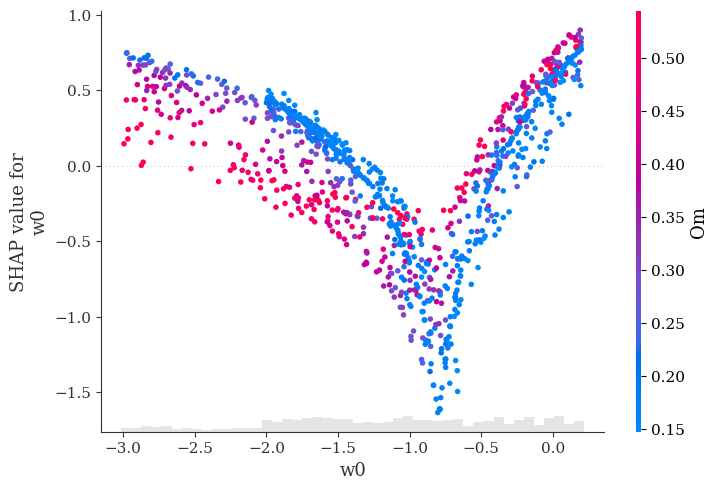

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_wa.png


<Figure size 640x480 with 0 Axes>

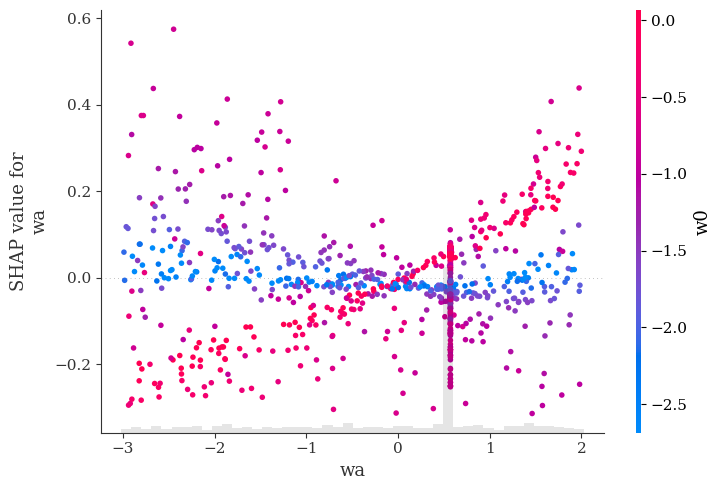

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_wa.png')]

In [36]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="w0waCDM no SH0ES · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="w0waCDM no SH0ES · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)


## <a id="1-8"></a>1.8 w0waCDM with z>0.25 — 4D, no Cepheids, no local flow

**Model:** `Flatw0waCDM` (Om, H0, w0, wa).
**Data:** Pantheon+ with an aggressive z>0.25 cut (no Cepheids, no local flow).
**Cepheids:** **NO**.

Extreme test: only high-z SNe. H0 is almost completely unconstrained.


In [37]:
SECTION = "1_8"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

# Aggressive z>0.25 cut, no calibrators
sne = load_pantheon_plus(apply_mask=True, z_min=0.25, keep_calibrators=False)
print(f"Pantheon+ z>0.25: {len(sne)} SNe (no Cepheids, no local flow)")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=False,
    )

# SN-only w0waCDM: wa no está restringida; se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, H0, w0: chi2_fn(Om=Om, H0=H0, w0=w0, wa=0.0), Om=0.3, H0=70.0, w0=-1.0)
_m.limits = [(0.15, 0.5), (60, 85), (-2.0, 0.0)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ z>0.25: 614 SNe (no Cepheids, no local flow)
Locating the global minimum with Nelder-Mead...
Auto-detected best-fit:  Om=0.3339  H0=60.0000  w0=-0.3749  wa=-1.8770
chi2(best-fit) = 482.51


In [38]:
def builder():
    N = 8_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.2), wa=(-3.0, 2.0), Om=REF['Om'], H0=REF['H0'], _n=N),
            dict(Om=(0.0, 0.5), w0=(-2.0, 0.2), wa=REF['wa'], H0=REF['H0'], _n=N),
            dict(H0=(65, 80), w0=(-2.0, 0.2), wa=REF['wa'], Om=REF['Om'], _n=N),
        ],
        random_box=dict(Om=(0.2, 0.6), H0=(60, 85), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_8_dataset.csv)
Evaluating chi2 at 42000 points across 11 cores...
     2000/42000 (  4.8%) | elapsed   11.5s | ETA  230.7s |    173 pts/s
     4000/42000 (  9.5%) | elapsed   22.4s | ETA  212.5s |    179 pts/s
     6000/42000 ( 14.3%) | elapsed   36.8s | ETA  221.0s |    163 pts/s
     8000/42000 ( 19.0%) | elapsed   47.6s | ETA  202.3s |    168 pts/s
    10000/42000 ( 23.8%) | elapsed   58.5s | ETA  187.1s |    171 pts/s
    12000/42000 ( 28.6%) | elapsed   68.2s | ETA  170.4s |    176 pts/s
    14000/42000 ( 33.3%) | elapsed   78.8s | ETA  157.7s |    178 pts/s
    16000/42000 ( 38.1%) | elapsed   89.9s | ETA  146.2s |    178 pts/s
    18000/42000 ( 42.9%) | elapsed  106.5s | ETA  142.0s |    169 pts/s
    20000/42000 ( 47.6%) | elapsed  116.9s | ETA  128.6s |    171 pts/s
    22000/42000 ( 52.4%) | elapsed  124.2s | ETA  112.9s |    177 pts/s
    24000/42000 ( 57.1%) | elapsed  138.6s | ETA  103.9s |  

  target in shifted-log10: range [0.000, 3.720]
  training: 12.83s | R2=0.99784 | best_iter=589/3000  (early stop, ~80% saved)
  model cached: 1_8_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_learning_curve.png


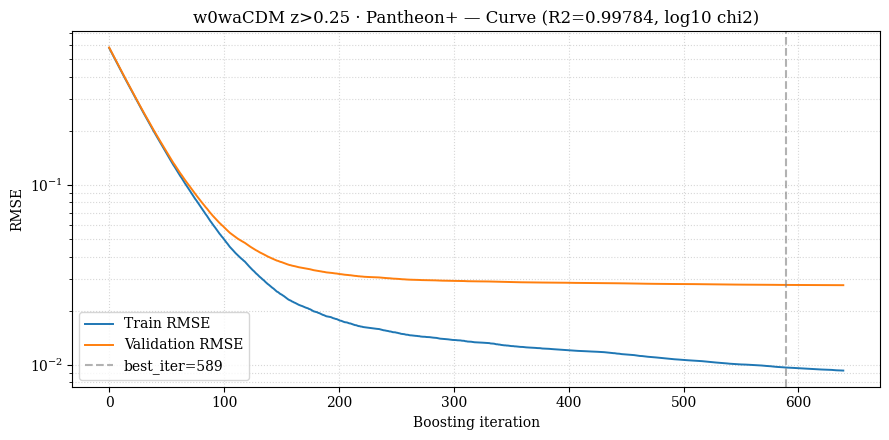

In [39]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"w0waCDM z>0.25 · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.37490047654797376, 'wa': -1.8770255163883574}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_H0.png


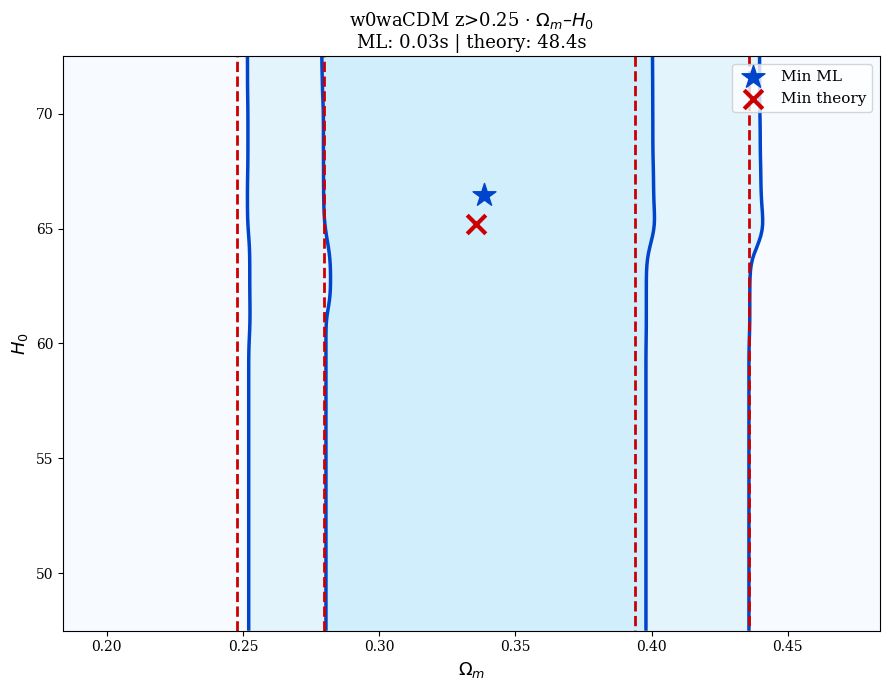

--- $w_0$ vs $\Omega_m$  ({'H0': 60.0, 'wa': -1.8770255163883574}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_w0.png


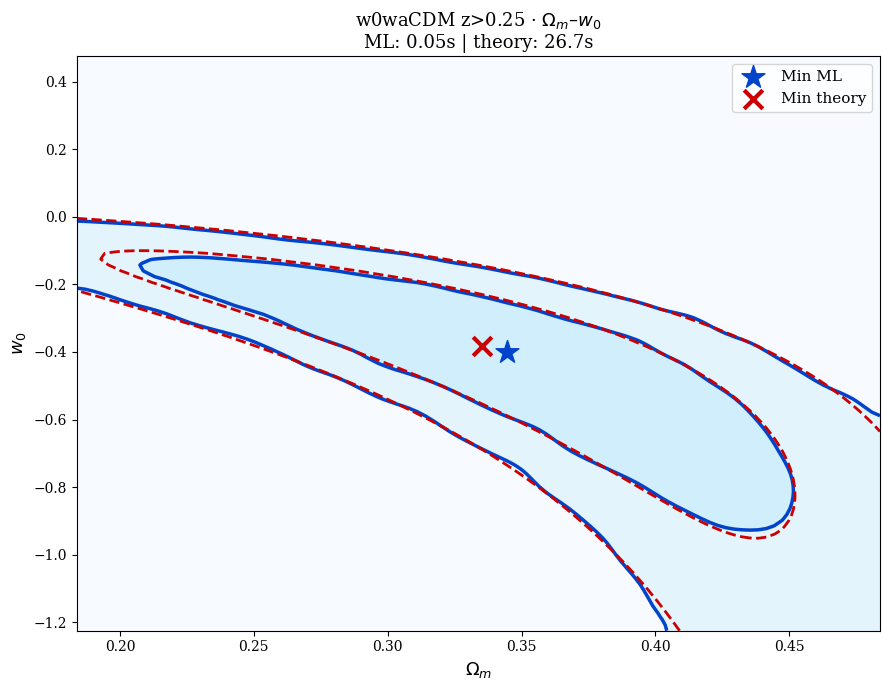

--- $w_a$ vs $\Omega_m$  ({'H0': 60.0, 'w0': -0.37490047654797376}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_wa.png


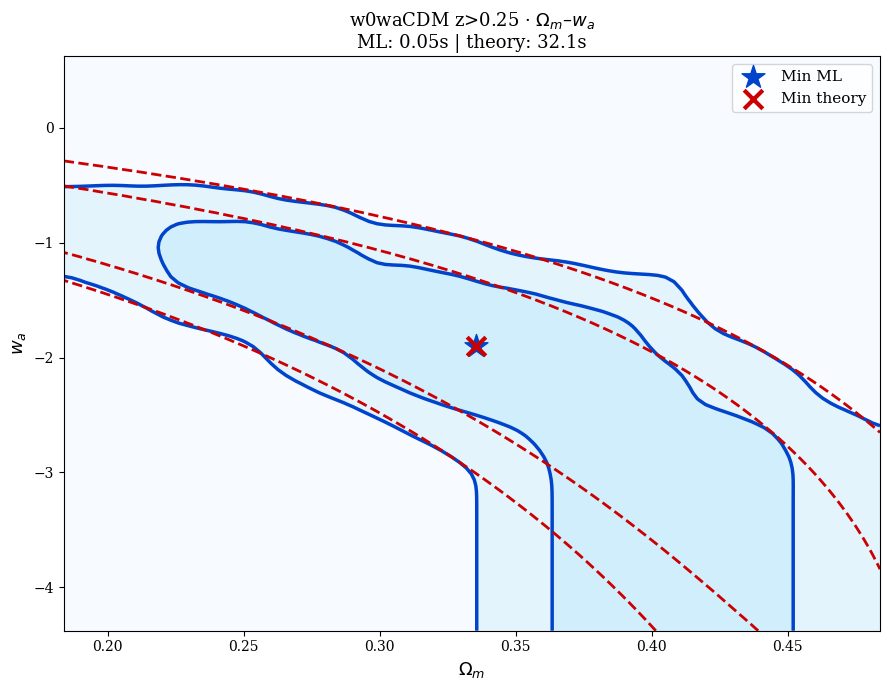

--- $w_0$ vs $H_0$  ({'Om': 0.333857138894446, 'wa': -1.8770255163883574}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_H0_w0.png


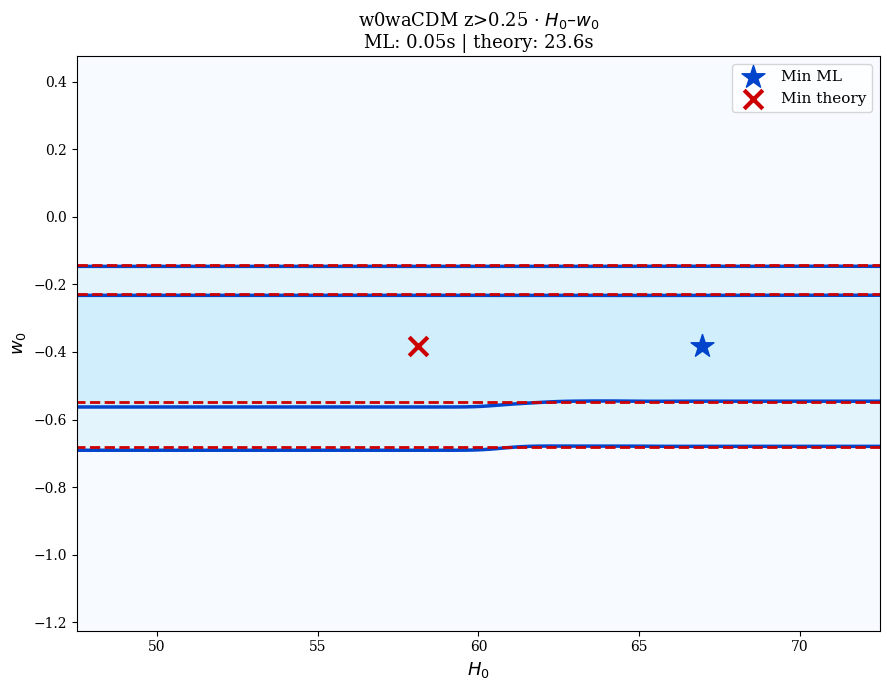

--- $w_a$ vs $H_0$  ({'Om': 0.333857138894446, 'w0': -0.37490047654797376}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_H0_wa.png


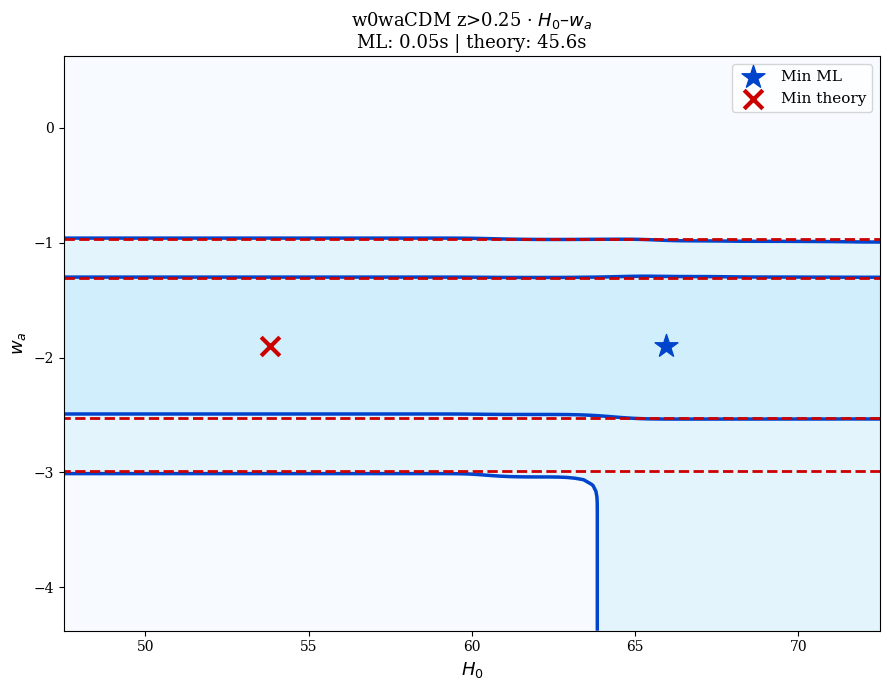

--- $w_a$ vs $w_0$  ({'Om': 0.333857138894446, 'H0': 60.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_w0_wa.png


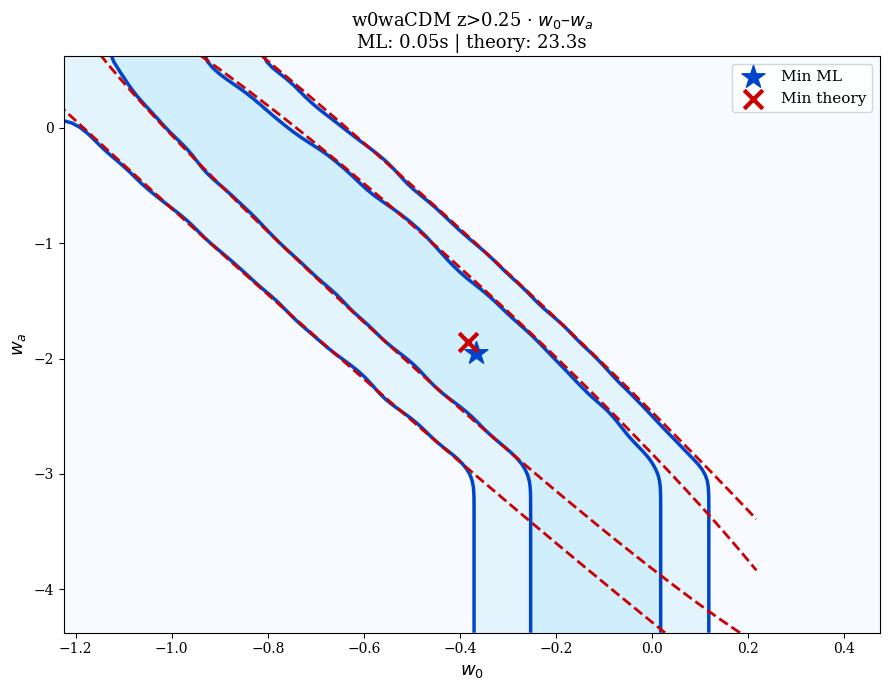

In [40]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.15, REF['Om']+0.15),
    H0=(REF['H0']-12.5, REF['H0']+12.5),
    w0=(REF['w0']-0.85, REF['w0']+0.85),
    wa=(REF['wa']-2.5, REF['wa']+2.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w0waCDM z>0.25 · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_beeswarm.png


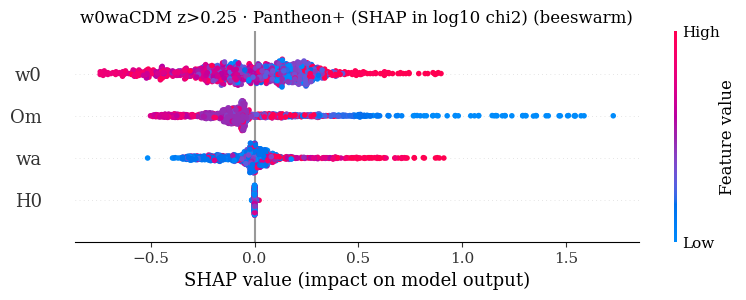

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_bar.png


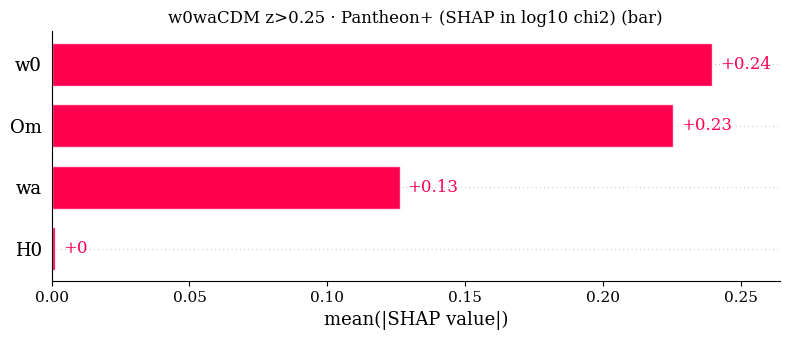

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_waterfall.png


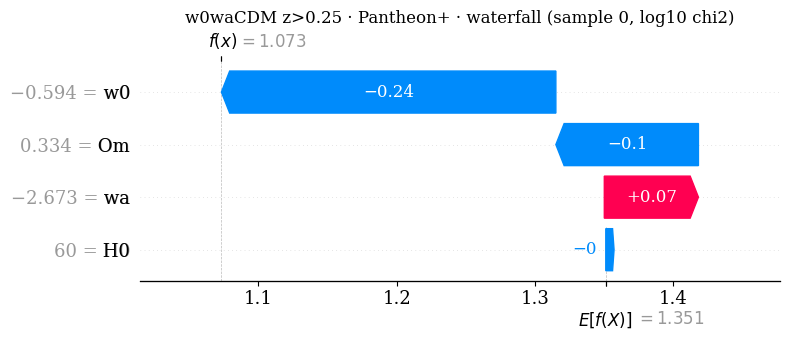

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_Om.png


<Figure size 640x480 with 0 Axes>

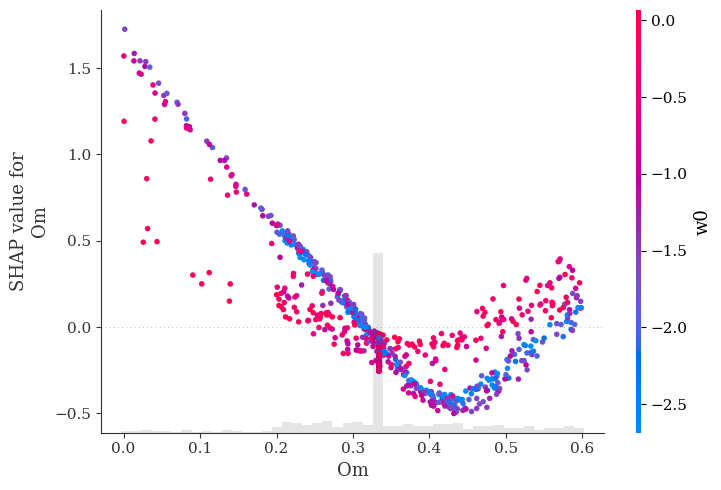

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_H0.png


<Figure size 640x480 with 0 Axes>

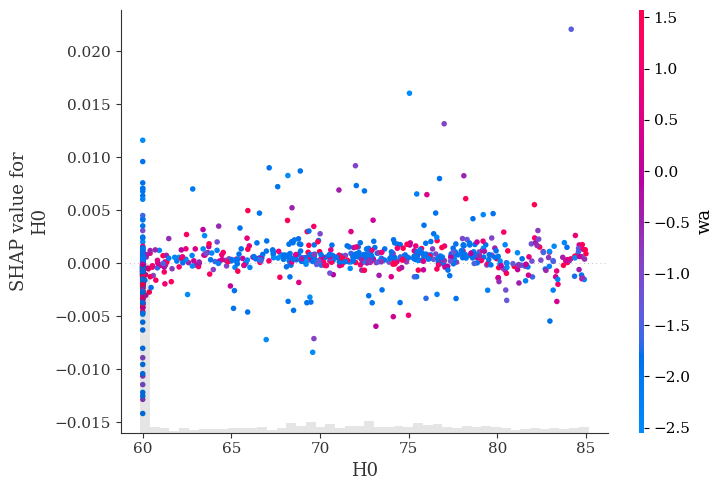

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_w0.png


<Figure size 640x480 with 0 Axes>

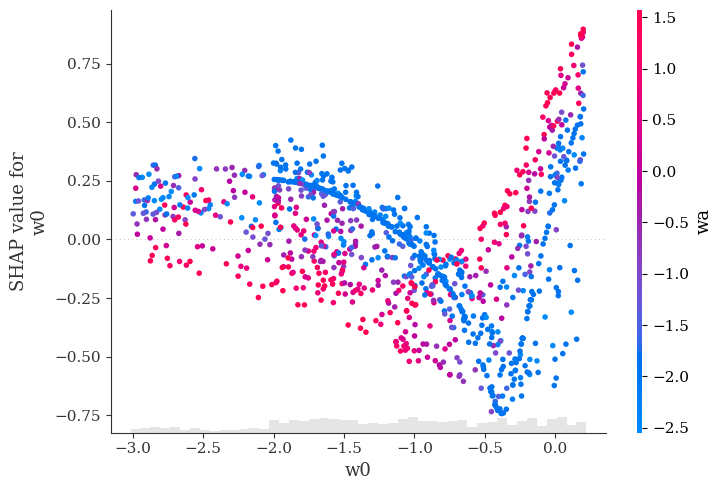

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_wa.png


<Figure size 640x480 with 0 Axes>

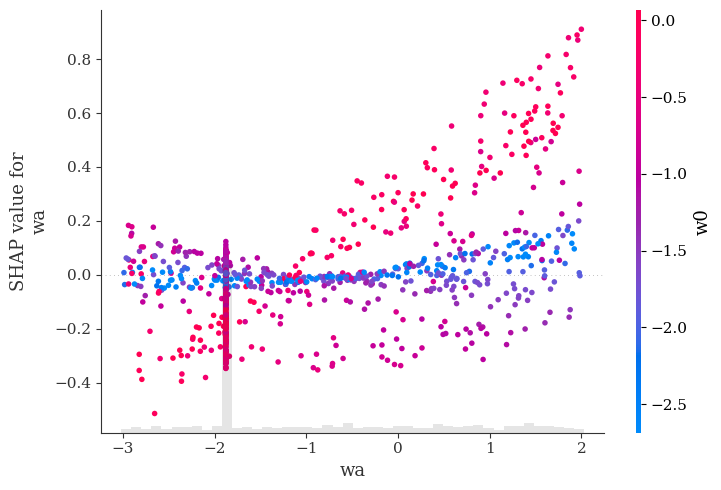

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_wa.png')]

In [41]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="w0waCDM z>0.25 · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="w0waCDM z>0.25 · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)
